# Heat Pump Installed Capacity Detection

Import Libraries

In [156]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import sys
import warnings
import time

import shap
import h5py

import xgboost as xgb

from matplotlib.patches import Polygon

from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from hyperopt.early_stop import no_progress_loss

from typing import Tuple

from matplotlib import colors

from math import ceil, floor
from scipy.stats import skew, kurtosis
from scipy.interpolate import griddata

from datetime import datetime, timedelta
from random import choice, sample, randrange, randint, uniform
from itertools import compress
from copy import deepcopy

from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error, mean_absolute_error, r2_score, mean_squared_error
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.decomposition import PCA

from scipy.optimize import least_squares, minimize, LinearConstraint, curve_fit
from scipy.signal import butter, sosfilt, welch
from scipy.stats import pearsonr, spearmanr, kendalltau

from pvlib import pvsystem, irradiance
from pvlib.location import Location
from pvlib.modelchain import ModelChain

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

from scikeras.wrappers import KerasRegressor

import cvxpy as cp

import missingno as msn

from tqdm import tqdm, trange
import pwlf

import hplib as hpl
# import hplib_database as db

In [145]:
regenerate_substations = True
retrain_xgb_time = True
retrain_xgb_time_pwlf = True
retrain_xgb_windowed_hdd = True

In [3]:
# or import heapo as a package - RECOMMENDED because Visual Studio Code then recognizes the package
folder_path = os.path.dirname(os.path.dirname(os.getcwd()))
sys.path.insert(0, folder_path)
sys.path.insert(0, folder_path + '/Desktop/NILM/src')
from heapo import *

# ---------------------------------------
# DEFINE PATH TO WHERE THE DATA IS STORED
# ---------------------------------------

# NOTE: if data is stored under /data/ within this repository --> set data_path = None 
data_path = 'data/heapo_data'

# ---------------------------------------
# CREATE HEAPO OBJECT
# ---------------------------------------

# create HEAPO object
heapo = HEAPO(data_path=data_path, use_local_time=False, suppress_warning=False)

Check households with submetered Heat Pumps

In [4]:
df_protocols = heapo.get_all_protocols()
households = heapo.get_all_households()

submeter_datarange = {}

start_date = '2023-01-01 00:00:00+00:00'
end_date = '2023-12-31 23:45:00+00:00'

full_year_no_weekends = pd.date_range(start=start_date, end=end_date, freq='15min')
# full_year_no_weekends = full_year_no_weekends[full_year_no_weekends.weekday < 5]  # only consider weekdays

for household_id in households:
    try:
        df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
        df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
        df_house.dropna(subset=['kWh_received_HeatPump', 'kWh_received_Total', 'kWh_received_Other'],inplace=True)
        # df_house = df_house[df_house['Timestamp'].dt.weekday < 5]        # only consider weekdays
        if len(df_house) > full_year_no_weekends.shape[0] * 0.8:  # only consider households with at least 80% of the data available
            submeter_datarange[household_id] = (df_house['Timestamp'].min(), df_house['Timestamp'].max(), len(df_house) * timedelta(minutes=15), full_year_no_weekends.shape[0] * timedelta(minutes=15) - len(df_house) * timedelta(minutes=15))
    except:
        pass


Get corresponding weather stations' IDs

In [5]:
df_meta = heapo.get_meta_data_overview()

datarangeDf = pd.DataFrame.from_dict(submeter_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)
datarangeDf = datarangeDf.join(df_meta.set_index('Household_ID')['Weather_ID'])

In [112]:
hp_peaks = []
for household_id in datarangeDf.index:
    df_house = heapo.load_smart_meter_data(household_id, resolution='15min')
    df_house = df_house[(df_house['Timestamp'] >= pd.to_datetime(start_date)) & (df_house['Timestamp'] <= pd.to_datetime(end_date))]
    # df_house = df_house[df_house['Timestamp'].dt.weekday < 5]        # only consider weekdays
    hp_load = df_house['kWh_received_HeatPump'].values * 4
    hp_load = hp_load[~np.isnan(hp_load)]
    hp_peak = hp_load.max()
    hp_99_9 = np.quantile(hp_load, 0.999)
    hp_time = df_house.iloc[np.argmax(hp_load)]['Timestamp']
    hp_peaks.append((hp_peak, hp_99_9, hp_time))

In [133]:
hp_peaks_df = pd.DataFrame({'Household_ID': datarangeDf.index, 'HP_Peak': [hp[0] for hp in hp_peaks], 'HP_99_9': [hp[1] for hp in hp_peaks], 'Timestamp': [hp[2] for hp in hp_peaks]})
hp_peaks_df.sort_values('HP_Peak', ascending=False, inplace=True)
hp_peaks_df

,Household_ID,HP_Peak,HP_99_9,Timestamp
44,1186910,28.388,20.030828,2023-02-28 00:30:00+00:00
32,611797,19.360,10.080684,2023-01-24 17:45:00+00:00
35,6687105,13.984,13.752000,2023-11-27 00:15:00+00:00
11,1181060,13.700,13.520000,2023-12-14 01:15:00+00:00
30,120706,12.820,9.787752,2023-04-13 06:15:00+00:00
22,818882,12.152,11.052228,2023-11-24 16:15:00+00:00
3,816910,11.704,9.220912,2023-02-10 08:00:00+00:00
6,884673,10.720,8.572456,2023-10-18 12:45:00+00:00
25,109105,10.672,10.392000,2023-01-21 03:15:00+00:00
47,667399,10.092,9.116000,2023-11-29 00:30:00+00:00


Check weather data availability

In [8]:
weather_ids = datarangeDf['Weather_ID'].unique()

weather_datarange = {}

full_year = pd.date_range(start=start_date, end=end_date, freq='h')
# full_year_no_weekends = full_year[full_year.weekday < 5]  # only consider weekdays

for weather_id in weather_ids:
    try:
        df_weather = heapo.load_weather_data(weather_id, resolution='hourly')
        df_weather = df_weather[(df_weather['Timestamp'] >= pd.to_datetime(start_date)) & (df_weather['Timestamp'] <= pd.to_datetime(end_date))]
        # df_weather = df_weather[df_weather['Timestamp'].dt.weekday < 5]        # only consider weekdays
        df_weather.dropna(subset=['Temperature_avg_hourly'],inplace=True)
        if len(df_weather) > full_year.shape[0] * 0.8: # at least 80% of data for one year
            weather_datarange[weather_id] = (df_weather['Timestamp'].min(), df_weather['Timestamp'].max(), len(df_weather) * timedelta(minutes=60), full_year.shape[0] * timedelta(minutes=60) - len(df_weather) * timedelta(minutes=60))
    except:
        pass

In [9]:
weather_datarangeDf = pd.DataFrame.from_dict(weather_datarange, orient='index', columns=['Start', 'End', 'Length', 'Missing Data']).sort_values('Length', ascending=False)

datarangeDf = datarangeDf[datarangeDf['Weather_ID'].isin(weather_datarangeDf.index)]

### Fit submetered HP load to temperature as piecewise linear function (Daily)

In [10]:
piece_lin_coeffs_hp = []

r2_score_list_hp = []

for id in tqdm(datarangeDf.index, desc='Fitting piecewise linear functions'):

    sm_data = heapo.load_smart_meter_data(id, resolution='15min')
    weather_data = heapo.load_weather_data(datarangeDf.loc[id, 'Weather_ID'], resolution='hourly')

    
    sm_data = sm_data.dropna(subset=['kWh_received_HeatPump'])
    sm_data = sm_data[(sm_data['Timestamp'] >= pd.to_datetime(start_date)) & (sm_data['Timestamp'] <= pd.to_datetime(end_date))]

    sm_data = (
        sm_data[['Timestamp', 'kWh_received_HeatPump']]
        .set_index('Timestamp')
        .resample('D')
        .sum()
        .reset_index()
    )

    weather_data = weather_data.dropna(subset=['Temperature_avg_hourly'])
    weather_data = weather_data[(weather_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) & (weather_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))]

    weather_data = (
        weather_data[['Timestamp', 'Temperature_avg_hourly']]
        .set_index('Timestamp')
        .resample('D')
        .mean()
        .reset_index()
    )
    # sm_data = sm_data[sm_data['Timestamp'].dt.weekday < 5]        # only consider weekdays for fitting piecewise linear functions

    x = weather_data['Temperature_avg_hourly'].values
    y = sm_data['kWh_received_HeatPump'].values
    try:
        plin = pwlf.PiecewiseLinFit(x, y)
        breakpoints = plin.fit(2)
        piece_lin_coeffs_hp.append((id, *breakpoints, *plin.slopes))
        r2_score_list_hp.append((id, plin.r_squared()))

    except:
        pass
    
piece_lin_coeffs_hp_df = pd.DataFrame(piece_lin_coeffs_hp, columns=['Household_ID', 'Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2'])
piece_lin_coeffs_hp_df.set_index('Household_ID', inplace=True)

r2_score_df = pd.DataFrame(r2_score_list_hp, columns=['Household_ID', 'R2_Score'])
r2_score_df.set_index('Household_ID', inplace=True)

Fitting piecewise linear functions: 100%|██████████| 57/57 [00:19<00:00,  2.89it/s]


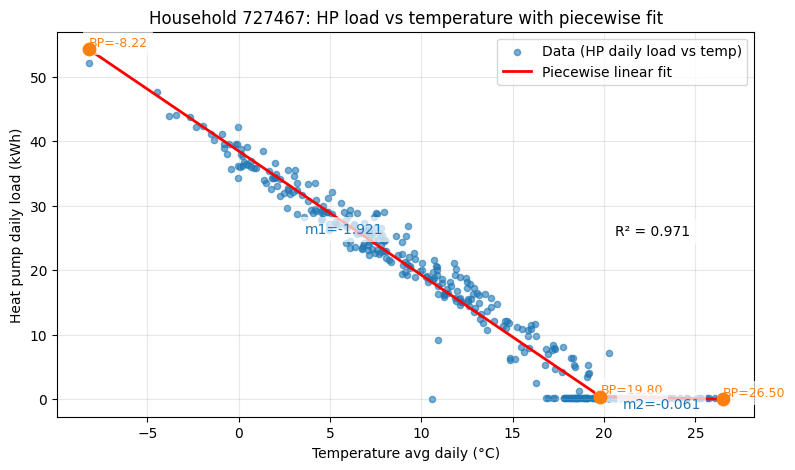

In [11]:
# example plot with one household and the existing y_fit
# pick a household for which we computed piecewise fit (from cell 13)
i = 1
example_id = datarangeDf.index[i]

df_example = heapo.load_smart_meter_data(example_id, resolution='15min')
weather_example = heapo.load_weather_data(datarangeDf.loc[example_id, 'Weather_ID'], resolution='hourly')

df_example = df_example.dropna(subset=['kWh_received_HeatPump'])
df_example = df_example[(df_example['Timestamp'] >= pd.to_datetime(start_date)) & (df_example['Timestamp'] <= pd.to_datetime(end_date))]
# df_example = df_example[df_example['Timestamp'].dt.weekday < 5]        # only consider weekdays for plotting

df_example = (
    df_example[['Timestamp', 'kWh_received_HeatPump']]
    .set_index('Timestamp')
    .resample('D')
    .sum()
    .reset_index()
)

weather_example = weather_example.dropna(subset=['Temperature_avg_hourly'])
weather_example = weather_example[(weather_example['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) & (weather_example['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))]

weather_example = (
    weather_example[['Timestamp', 'Temperature_avg_hourly']]
    .set_index('Timestamp')
    .resample('D')
    .mean()
    .reset_index()
)


x = weather_example['Temperature_avg_hourly'].values
y = df_example['kWh_received_HeatPump'].values

plin = pwlf.PiecewiseLinFit(x, y)
breakpoints = plin.fit(2)

# make x_fit consistent with y_fit length
x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = plin.predict(x_hat)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Data (HP daily load vs temp)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Piecewise linear fit')
plt.xlabel('Temperature avg daily (°C)')
plt.ylabel('Heat pump daily load (kWh)')
plt.title(f'Household {example_id}: HP load vs temperature with piecewise fit')
plt.legend()
plt.grid(alpha=0.3)
r2 = r2_score_df.loc[example_id, 'R2_Score'] if 'r2_score_df' in globals() and example_id in r2_score_df.index else plin.r_squared()
plt.text(0.80, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# annotate breakpoints and slopes
for bp in breakpoints:
    y_bp = plin.predict(bp)
    plt.scatter(bp, y_bp, color='tab:orange', s=80, zorder=6)
    # plt.axvline(bp, color='tab:orange', linestyle='--', alpha=0.7)
    plt.text(bp, y_bp, f'BP={bp:.2f}', color='tab:orange', fontsize=9, rotation=0,
             ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for i, slope in enumerate(plin.slopes):
    x0 = breakpoints[i]
    x1 = breakpoints[i+1]
    xm = (x0 + x1) / 2
    ym = plin.predict(xm)
    plt.text(xm, ym, f'm{i+1}={slope:.3f}', color='tab:blue', fontsize=10,
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

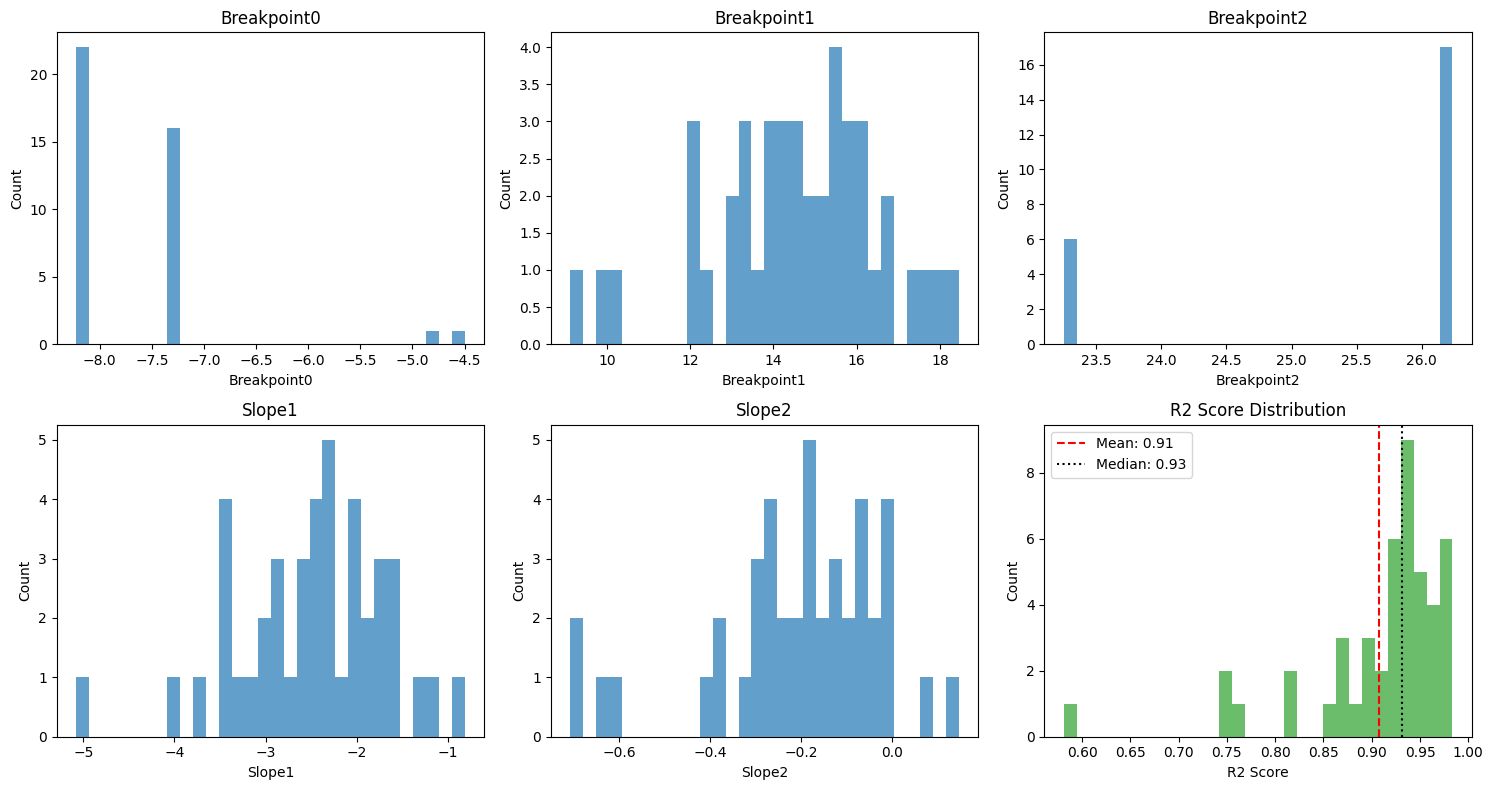

In [12]:
cols = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2']

fig, axs = plt.subplots(2, 3, figsize=(15, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser = piece_lin_coeffs_hp_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')

if 'r2_score_df' in globals() and not r2_score_df.empty:
    r2_scores = r2_score_df['R2_Score'].dropna()
    ax = axs[i+1]
    ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
    ax.set_title('R2 Score Distribution')
    ax.set_xlabel('R2 Score')
    ax.set_ylabel('Count')
    ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
    ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
    ax.legend()
else:
    axs[len(cols)].text(0.5, 0.5, 'No R2 score data', ha='center', va='center')

# # remove empty axis
# if len(cols) < len(axs):
#     for j in range(len(cols), len(axs)):
#         fig.delaxes(axs[j])

fig.tight_layout()
plt.show()

### Fit smart meter load to temperature as a piecewise linear function (DAILY)

In [13]:
piece_lin_coeffs = []

r2_score_list = []

for id in tqdm(datarangeDf.index, desc='Fitting piecewise linear functions'):

    sm_data = heapo.load_smart_meter_data(id, resolution='15min')
    weather_data = heapo.load_weather_data(datarangeDf.loc[id, 'Weather_ID'], resolution='hourly')

    sm_data = sm_data.dropna(subset=['kWh_received_Total'])
    sm_data = sm_data[(sm_data['Timestamp'] >= pd.to_datetime(start_date)) & (sm_data['Timestamp'] <= pd.to_datetime(end_date))]
    # sm_data = sm_data[sm_data['Timestamp'].dt.weekday < 5]  # only consider weekdays
    sm_data = (
        sm_data[['Timestamp', 'kWh_received_Total']]
        .set_index('Timestamp')
        .resample('D')
        .sum()
        .reset_index()
    )

    weather_data = weather_data.dropna(subset=['Temperature_avg_hourly'])
    weather_data = weather_data[(weather_data['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) & (weather_data['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))]
    weather_data = (
        weather_data[['Timestamp', 'Temperature_avg_hourly']]
        .set_index('Timestamp')
        .resample('D')
        .mean()
        .reset_index()
    )

    x = weather_data['Temperature_avg_hourly'].values
    y = sm_data['kWh_received_Total'].values
    try:
        plin = pwlf.PiecewiseLinFit(x, y)
        breakpoints = plin.fit(2)
        piece_lin_coeffs.append((id, *breakpoints, *plin.slopes))
        r2_score_list.append((id, plin.r_squared()))

    except:
        pass
    
piece_lin_coeffs_df = pd.DataFrame(piece_lin_coeffs, columns=['Household_ID', 'Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2'])
piece_lin_coeffs_df.set_index('Household_ID', inplace=True)

r2_score_df = pd.DataFrame(r2_score_list, columns=['Household_ID', 'R2_Score'])
r2_score_df.set_index('Household_ID', inplace=True)

Fitting piecewise linear functions: 100%|██████████| 57/57 [00:19<00:00,  2.93it/s]


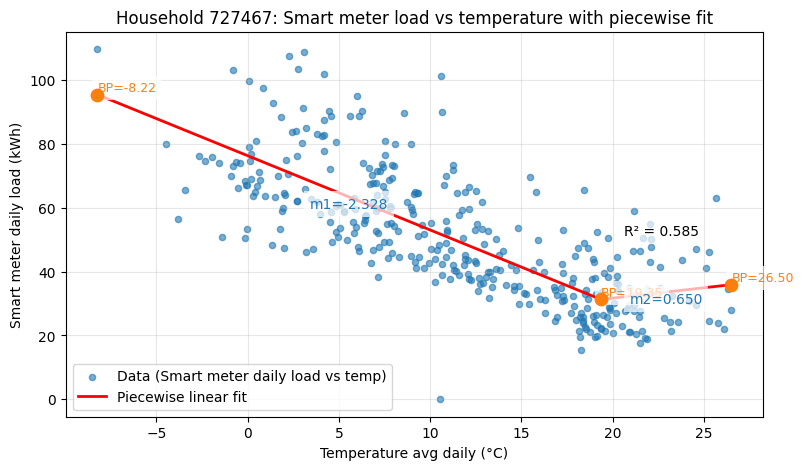

In [14]:
# example plot with one household and the existing y_fit
# pick a household for which we computed piecewise fit (from cell 13)
i = 1

example_id = datarangeDf.index[i]

df_example = heapo.load_smart_meter_data(example_id, resolution='15min')
weather_example = heapo.load_weather_data(datarangeDf.loc[example_id, 'Weather_ID'], resolution='hourly')

df_example = df_example.dropna(subset=['kWh_received_Total'])
df_example = df_example[(df_example['Timestamp'] >= pd.to_datetime(start_date)) & (df_example['Timestamp'] <= pd.to_datetime(end_date))]
# df_example = df_example[df_example['Timestamp'].dt.weekday < 5]        # only consider weekdays for plotting
df_example = (
    df_example[['Timestamp', 'kWh_received_Total']]
    .set_index('Timestamp')
    .resample('D')
    .sum()
    .reset_index()
)
weather_example = weather_example.dropna(subset=['Temperature_avg_hourly'])
weather_example = weather_example[(weather_example['Timestamp'] >= pd.Timestamp(start_date, tz='UTC')) & (weather_example['Timestamp'] <= pd.Timestamp(end_date, tz='UTC'))]
weather_example = (
    weather_example[['Timestamp', 'Temperature_avg_hourly']]
    .set_index('Timestamp')
    .resample('D')
    .mean()
    .reset_index()
)

x = weather_example['Temperature_avg_hourly'].values
y = df_example['kWh_received_Total'].values

plin = pwlf.PiecewiseLinFit(x, y)
breakpoints = plin.fit(2)

# make x_fit consistent with y_fit length
x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = plin.predict(x_hat)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Data (Smart meter daily load vs temp)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Piecewise linear fit')
plt.xlabel('Temperature avg daily (°C)')
plt.ylabel('Smart meter daily load (kWh)')
plt.title(f'Household {example_id}: Smart meter load vs temperature with piecewise fit')
plt.legend()
plt.grid(alpha=0.3)
r2 = r2_score_df.loc[example_id, 'R2_Score'] if 'r2_score_df' in globals() and example_id in r2_score_df.index else plin.r_squared()
plt.text(0.80, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# annotate breakpoints and slopes
for bp in breakpoints:
    y_bp = plin.predict(bp)
    plt.scatter(bp, y_bp, color='tab:orange', s=80, zorder=6)
    # plt.axvline(bp, color='tab:orange', linestyle='--', alpha=0.7)
    plt.text(bp, y_bp, f'BP={bp:.2f}', color='tab:orange', fontsize=9, rotation=0,
             ha='left', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

for i, slope in enumerate(plin.slopes):
    x0 = breakpoints[i]
    x1 = breakpoints[i+1]
    xm = (x0 + x1) / 2
    ym = plin.predict(xm)
    plt.text(xm, ym, f'm{i+1}={slope:.3f}', color='tab:blue', fontsize=10,
             ha='center', va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

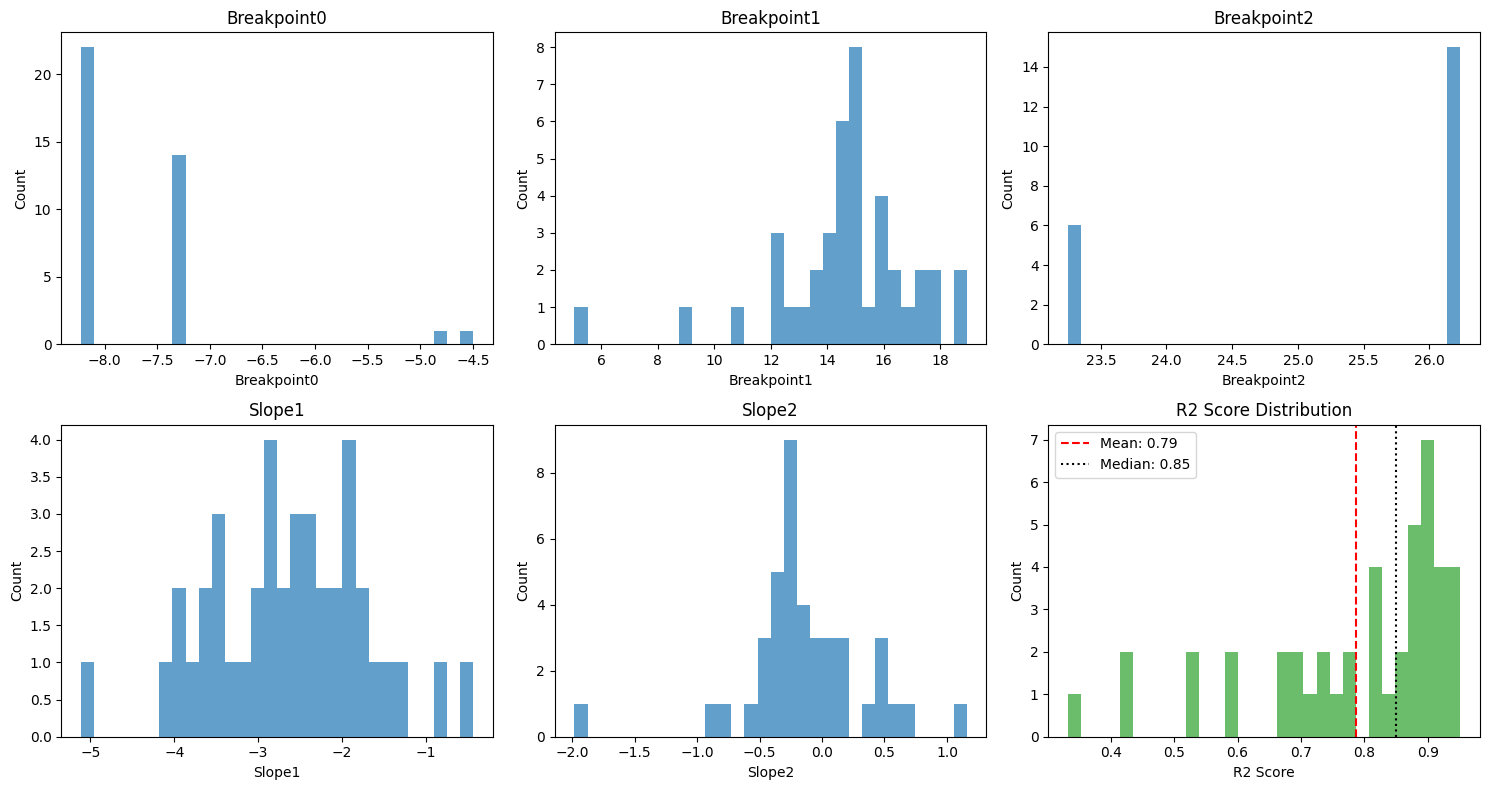

In [15]:
if 'piece_lin_coeffs_df' in globals() and not piece_lin_coeffs_df.empty:
    cols = ['Breakpoint0', 'Breakpoint1', 'Breakpoint2', 'Slope1', 'Slope2']

    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    axs = axs.flatten()

    for i, col in enumerate(cols):
        ser = piece_lin_coeffs_df[col].dropna()
        ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
        axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
        axs[i].set_title(col)
        axs[i].set_xlabel(col)
        axs[i].set_ylabel('Count')

    if 'r2_score_df' in globals() and not r2_score_df.empty:
        r2_scores = r2_score_df['R2_Score'].dropna()
        ax = axs[i+1]
        ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
        ax.set_title('R2 Score Distribution')
        ax.set_xlabel('R2 Score')
        ax.set_ylabel('Count')
        ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
        ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
        ax.legend()
    else:
        axs[len(cols)].text(0.5, 0.5, 'No R2 score data', ha='center', va='center')

    # # remove empty axis
    # if len(cols) < len(axs):
    #     for j in range(len(cols), len(axs)):
    #         fig.delaxes(axs[j])

    fig.tight_layout()
    plt.show()
else:
    print("piece_lin_coeffs_df is not available or empty")

### Create synthetic substations

In [18]:
all_smd = heapo.load_smart_meter_data_multiple(datarangeDf.index.tolist(), resolution='15min')
all_smd = all_smd[(all_smd['Timestamp'] >= pd.to_datetime(start_date)) & (all_smd['Timestamp'] <= pd.to_datetime(end_date))]
# all_smd = all_smd[all_smd['Timestamp'].dt.weekday < 5]        # only consider weekdays

In [19]:
if regenerate_substations:
    n_substations = 2000

    substations = {}

    min_substation_size = 2
    max_substation_size = 100

    T_base = 12.0  # degC, balance temperature for heating degree hours (HDH)

    available_households = list(datarangeDf.index)
    available_weather_ids = list(datarangeDf['Weather_ID'])

    datetime_range = pd.date_range(start=start_date, end=end_date, freq='15min')
    # datetime_range = datetime_range[datetime_range.weekday < 5]  # only consider weekdays

    for i in trange(n_substations, desc='Generating substations'):

        hp_ratio = uniform(0.1, 1.0) # ratio of households with heat pump in substation
        substation_size = randint(min_substation_size, max_substation_size) # number of households in substation

        n_hps = int(hp_ratio * substation_size)

        substations[i] = {
            'size': substation_size,
            'HP_ratio': hp_ratio,
        }

        weather_station = sample(available_weather_ids, 1)[0] # randomly select weather station
        substations[i]['weather_id'] = weather_station

        households_hp = datarangeDf[datarangeDf['Weather_ID'] == weather_station].sample(n_hps, replace=True).index.tolist() # randomly select households with this weather station
        substations[i]['households_hp'] = households_hp

        households = datarangeDf.sample(substation_size - n_hps, replace=True).index.tolist()
        substations[i]['households'] = households

        substations[i]['HP_Load'] = pd.Series(0, index=datetime_range)
        substations[i]['Total_Load'] = pd.Series(0, index=datetime_range)

        for household_id in households_hp:
            smd_hp = all_smd[all_smd['Household_ID'] == household_id]
            smd_hp = smd_hp.set_index('Timestamp')
            smd_hp = smd_hp.sort_index()
            substations[i]['HP_Load'] += smd_hp['kWh_received_HeatPump'].reindex(datetime_range).interpolate(method='time').fillna(0)
            substations[i]['Total_Load'] += smd_hp['kWh_received_Other'].reindex(datetime_range).interpolate(method='time').fillna(0) + smd_hp['kWh_received_HeatPump'].reindex(datetime_range).interpolate(method='time').fillna(0)

        for household_id in households:
            smd = all_smd[all_smd['Household_ID'] == household_id]
            smd = smd.set_index('Timestamp')
            smd = smd.sort_index()
            substations[i]['Total_Load'] += smd['kWh_received_Other'].reindex(datetime_range).interpolate(method='time').fillna(0)

        substations[i]['HP_Load'] = substations[i]['HP_Load'] * 4 # convert to kW
        substations[i]['Total_Load'] = substations[i]['Total_Load'] * 4 # convert to kW

        weather_data = heapo.load_weather_data(weather_station, resolution='hourly')
        weather_data = weather_data[(weather_data['Timestamp'] >= pd.to_datetime(start_date)) & (weather_data['Timestamp'] <= pd.to_datetime(end_date))][['Timestamp', 'Temperature_avg_hourly']]
        # weather_data = weather_data[weather_data['Timestamp'].dt.weekday < 5]        # only consider weekdays
        weather_data = weather_data.set_index('Timestamp')
        weather_data = weather_data.resample('15min').interpolate(method='time')

        substations[i]['Temperature'] = weather_data['Temperature_avg_hourly']

        substations[i]['HP_Peak'] = np.sum([hp_peaks_df[hp_peaks_df['Household_ID'] == household_id]['HP_Peak'].values[0] for household_id in households_hp])

    # Save substations data
    substations_df = pd.DataFrame.from_dict(substations, orient='index')
    pickle.dump(substations_df, open('data/substations_data.pkl', 'wb'))
else:
    substations_df = pickle.load(open('data/substations_data.pkl', 'rb'))

Generating substations: 100%|██████████| 2000/2000 [20:30<00:00,  1.62it/s]


In [21]:
substations_df = substations_df.fillna(0)
substations_df_train, substations_df_test = train_test_split(substations_df, test_size=0.5, random_state=42)

### Fite piecewise function to substation net load

In [23]:
# ---------------------------------------------------------------------------
# Hockey-stick model: Load(T) = base_load + hp_sensitivity * max(0, T_balance - T)
#
# Replaces the unconstrained 2-segment pwlf fit used throughout this
# section. Unconstrained pwlf has 5 free parameters and can land on
# degenerate solutions (positive cold-weather slopes, breakpoints outside
# the heating range) -- the original code patched this after the fact
# (`if slopes[0] > 0: slopes[0] = 0`). This model has only 3 parameters,
# all physically bounded, so degenerate fits can't happen in the first
# place, and `hp_sensitivity` maps directly onto installed HP capacity.
# ---------------------------------------------------------------------------
from scipy.optimize import curve_fit


def hockey_stick(T, base_load, hp_sensitivity, T_balance):
    return base_load + hp_sensitivity * np.maximum(0, T_balance - T)


def fit_hockey_stick(x, y, T_balance_bounds=(8, 20)):
    """Fit a 3-parameter hockey-stick load-vs-temperature curve.

    Returns (base_load, hp_sensitivity, T_balance, r2). Raises if curve_fit
    fails (e.g. too few / degenerate points) so callers can catch and skip.
    """
    p0 = [np.median(y), 0.5, np.mean(T_balance_bounds)]
    bounds = (
        [0, 0, T_balance_bounds[0]],
        [np.inf, np.inf, T_balance_bounds[1]]
    )
    popt, _ = curve_fit(hockey_stick, x, y, p0=p0, bounds=bounds, maxfev=5000)
    y_pred = hockey_stick(x, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    base_load, hp_sensitivity, T_balance = popt
    return base_load, hp_sensitivity, T_balance, r2


def daily_min_max_heating_season(temperature, load, heating_season_thresh=16.0):
    """Build (daily_min_temperature, daily_max_load) pairs, restricted to
    heating-season days.

    Using the daily MINIMUM temperature (rather than the daily mean) ties
    the fit to the coldest part of the day, when HPs run hardest. Using the
    daily MAXIMUM load (rather than the mean) ties it to peak demand, which
    is what HP_Peak actually measures. Warm-season days are dropped so they
    don't bias the slope / balance-temperature estimate towards a flat,
    near-zero-sensitivity cloud of points.
    """
    daily_temp_min = temperature.resample('D').min()
    daily_load_max = load.resample('D').max()
    sm_data = pd.DataFrame({
        'Temperature_min': daily_temp_min,
        'Total_Load_max': daily_load_max
    }).dropna()
    sm_data = sm_data[sm_data['Temperature_min'] < heating_season_thresh]
    return sm_data['Temperature_min'].values, sm_data['Total_Load_max'].values


T_BALANCE_BOUNDS = (8, 20)     # degC, plausible balance-temperature range
HEATING_SEASON_THRESH = 12.0   # degC, daily-min threshold to keep a day
MIN_HEATING_DAYS = 20          # minimum heating-season days required to attempt a fit

In [24]:
piece_lin_coeff_sub = []
r2_score_sub = []

for id in tqdm(substations_df_train.index, desc='Fitting hockey-stick model for substations'):
    try:
        x, y = daily_min_max_heating_season(
            substations_df_train.loc[id, 'Temperature'],
            substations_df_train.loc[id, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH
        )

        if len(x) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        r2_score_sub.append((id, r2))
        piece_lin_coeff_sub.append((id, base_load, hp_sensitivity, T_balance))

    except Exception:
        pass

Fitting hockey-stick model for substations: 100%|██████████| 1000/1000 [00:06<00:00, 158.76it/s]


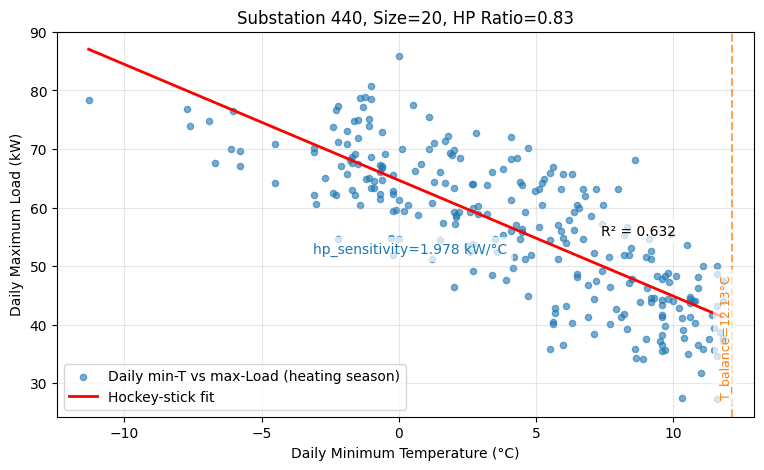

In [114]:
cols = ['Base_Load', 'HP_Sensitivity', 'T_Balance']

piece_lin_coeff_train_df = pd.DataFrame(piece_lin_coeff_sub, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance'])
piece_lin_coeff_train_df.set_index('Substation_ID', inplace=True)

r2_score_train_df = pd.DataFrame(r2_score_sub, columns=['Substation_ID', 'R2_Score'])
r2_score_train_df.set_index('Substation_ID', inplace=True)

# example plot with one substation and the fitted hockey-stick curve
i = 0
example_id = int(piece_lin_coeff_train_df.index.values[i])

x, y = daily_min_max_heating_season(
    substations_df_train.loc[example_id, 'Temperature'],
    substations_df_train.loc[example_id, 'Total_Load'],
    heating_season_thresh=HEATING_SEASON_THRESH
)

base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

x_hat = np.linspace(x.min(), x.max(), 100)
y_hat = hockey_stick(x_hat, base_load, hp_sensitivity, T_balance)

plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=20, alpha=0.6, label='Daily min-T vs max-Load (heating season)')
plt.plot(x_hat, y_hat, color='red', lw=2, label='Hockey-stick fit')
plt.xlabel('Daily Minimum Temperature (°C)')
plt.ylabel('Daily Maximum Load (kW)')
plt.title(f"Substation {example_id}, Size={substations_df_train.loc[example_id, 'size']}, "
          f"HP Ratio={substations_df_train.loc[example_id, 'HP_ratio']:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.text(0.78, 0.5, f'R² = {r2:.3f}', transform=plt.gca().transAxes, fontsize=10, va='top',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.axvline(T_balance, color='tab:orange', linestyle='--', alpha=0.7)
plt.text(T_balance, y.min(), f'T_balance={T_balance:.2f}°C', color='tab:orange', fontsize=9,
         rotation=90, ha='right', va='bottom', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.text((x.min() + T_balance) / 2, y_hat.max() * 0.6, f'hp_sensitivity={hp_sensitivity:.3f} kW/°C',
         color='tab:blue', fontsize=10, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.show()

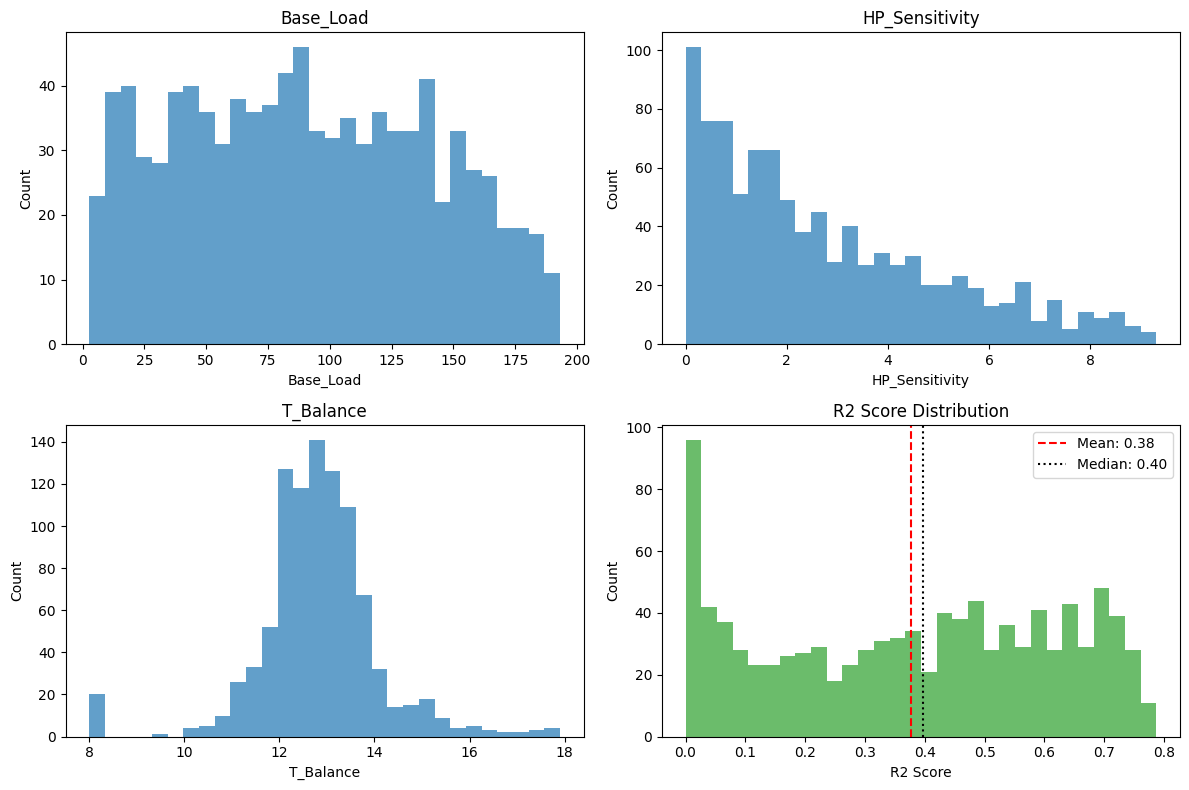

In [26]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.flatten()

for i, col in enumerate(cols):
    ser = piece_lin_coeff_train_df[col].dropna()
    ser = ser[np.abs(ser) < np.percentile(np.abs(ser), 95)]  # remove outliers for better visualization
    axs[i].hist(ser, bins=30, color='tab:blue', alpha=0.7)
    axs[i].set_title(col)
    axs[i].set_xlabel(col)
    axs[i].set_ylabel('Count')


r2_scores = r2_score_train_df['R2_Score'].dropna()
ax = axs[i+1]
ax.hist(r2_scores, bins=30, color='tab:green', alpha=0.7)
ax.set_title('R2 Score Distribution')
ax.set_xlabel('R2 Score')
ax.set_ylabel('Count')
ax.axvline(r2_scores.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {r2_scores.mean():.2f}')
ax.axvline(r2_scores.median(), color='black', linestyle=':', linewidth=1.5, label=f'Median: {r2_scores.median():.2f}')
ax.legend()
fig.tight_layout()
plt.show()

R² for HP_Sensitivity vs Simultaneous HP Peak: 0.796
31.019, 20.181
R² for HP_Sensitivity_per_hh vs Simultaneous HP Peak: 0.287


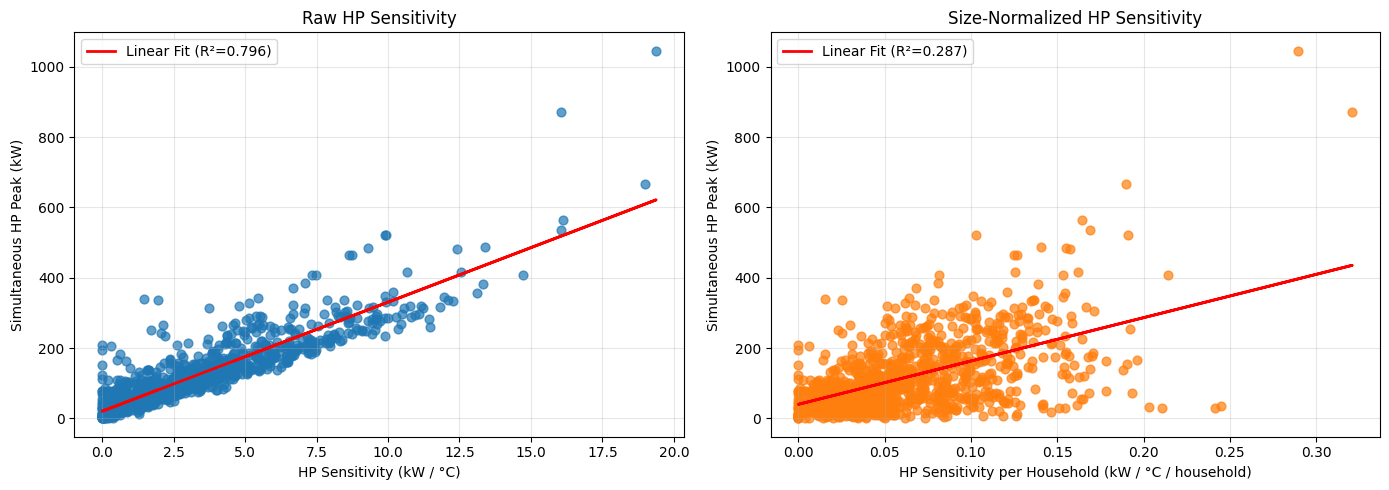

In [27]:
substations_df_train['Simult_HP_Peak'] = [substations_df_train.iloc[i]['HP_Load'].max() if hp_ratio > 0 else 0 for i, hp_ratio in enumerate(substations_df_train['HP_ratio'])]

data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train[['Simult_HP_Peak', 'size']])
data['HP_Sensitivity_per_hh'] = data['HP_Sensitivity'] / data['size']

lin = LinearRegression()
lin.fit(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
r2 = lin.score(data[['HP_Sensitivity']], data['Simult_HP_Peak'])
print(f"R² for HP_Sensitivity vs Simultaneous HP Peak: {r2:.3f}")
print(f"{lin.coef_[0]:.3f}, {lin.intercept_:.3f}")

lin_norm = LinearRegression()
lin_norm.fit(data[['HP_Sensitivity_per_hh']], data['Simult_HP_Peak'])
r2_norm = lin_norm.score(data[['HP_Sensitivity_per_hh']], data['Simult_HP_Peak'])
print(f"R² for HP_Sensitivity_per_hh vs Simultaneous HP Peak: {r2_norm:.3f}")

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
axs[0].scatter(data['HP_Sensitivity'], data['Simult_HP_Peak'], alpha=0.7, s=40)
axs[0].plot(data['HP_Sensitivity'], lin.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2:.3f})')
axs[0].set_xlabel('HP Sensitivity (kW / °C)')
axs[0].set_ylabel('Simultaneous HP Peak (kW)')
axs[0].set_title('Raw HP Sensitivity')
axs[0].grid(alpha=0.3)
axs[0].legend()

axs[1].scatter(data['HP_Sensitivity_per_hh'], data['Simult_HP_Peak'], alpha=0.7, s=40, color='tab:orange')
axs[1].plot(data['HP_Sensitivity_per_hh'], lin_norm.predict(data[['HP_Sensitivity_per_hh']]), color='red', linewidth=2, label=f'Linear Fit (R²={r2_norm:.3f})')
axs[1].set_xlabel('HP Sensitivity per Household (kW / °C / household)')
axs[1].set_ylabel('Simultaneous HP Peak (kW)')
axs[1].set_title('Size-Normalized HP Sensitivity')
axs[1].grid(alpha=0.3)
axs[1].legend()

fig.tight_layout()
plt.show()

R² for HP_Sensitivity vs Non-Simultaneous HP Peak: 0.871
47.980, 28.690


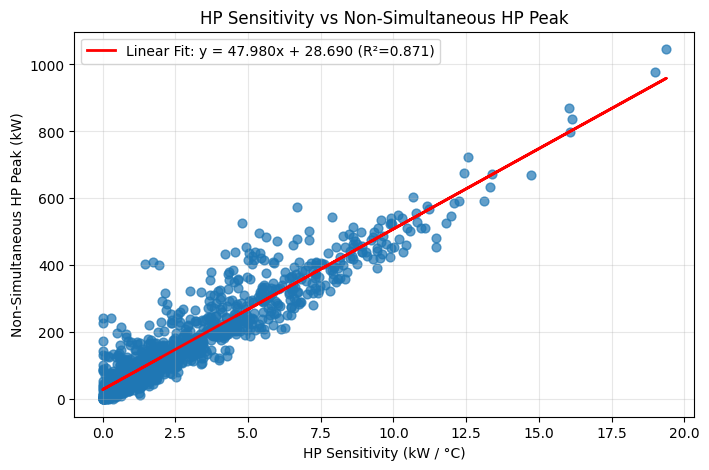

In [28]:
data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train[['HP_Peak', 'size']])
data['HP_Sensitivity_per_hh'] = data['HP_Sensitivity'] / data['size']

nonSimDeltaFit = LinearRegression()
nonSimDeltaFit.fit(data[['HP_Sensitivity']], data['HP_Peak'])
r2 = nonSimDeltaFit.score(data[['HP_Sensitivity']], data['HP_Peak'])
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak: {r2:.3f}")
print(f"{nonSimDeltaFit.coef_[0]:.3f}, {nonSimDeltaFit.intercept_:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data['HP_Sensitivity'], data['HP_Peak'], alpha=0.7, s=40)
plt.plot(data['HP_Sensitivity'], nonSimDeltaFit.predict(data[['HP_Sensitivity']]), color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [29]:
piece_lin_coeff_test = []
r2_score_test = []

for id in tqdm(substations_df_test.index, desc='Fitting hockey-stick model for substations (test)'):
    try:
        x, y = daily_min_max_heating_season(
            substations_df_test.loc[id, 'Temperature'],
            substations_df_test.loc[id, 'Total_Load'],
            heating_season_thresh=HEATING_SEASON_THRESH
        )

        if len(x) < MIN_HEATING_DAYS:
            continue

        base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)

        r2_score_test.append((id, r2))
        piece_lin_coeff_test.append((id, base_load, hp_sensitivity, T_balance))

    except Exception:
        pass

Fitting hockey-stick model for substations (test): 100%|██████████| 1000/1000 [00:06<00:00, 159.01it/s]


In [30]:
piece_lin_coeff_test_df = pd.DataFrame(piece_lin_coeff_test, columns=['Substation_ID', 'Base_Load', 'HP_Sensitivity', 'T_Balance'])
piece_lin_coeff_test_df.set_index('Substation_ID', inplace=True)

r2_score_test_df = pd.DataFrame(r2_score_test, columns=['Substation_ID', 'R2_Score'])
r2_score_test_df.set_index('Substation_ID', inplace=True)

In [31]:
piece_lin_coeff_df = pd.concat([piece_lin_coeff_train_df, piece_lin_coeff_test_df])
r2_score_df = pd.concat([r2_score_train_df, r2_score_test_df])

R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: 0.888


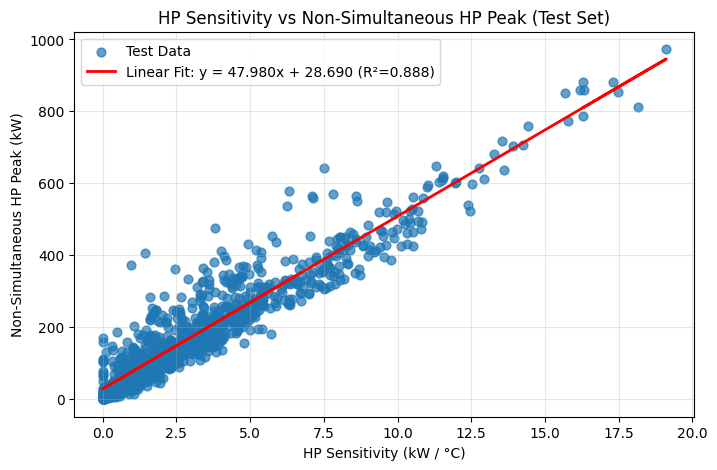

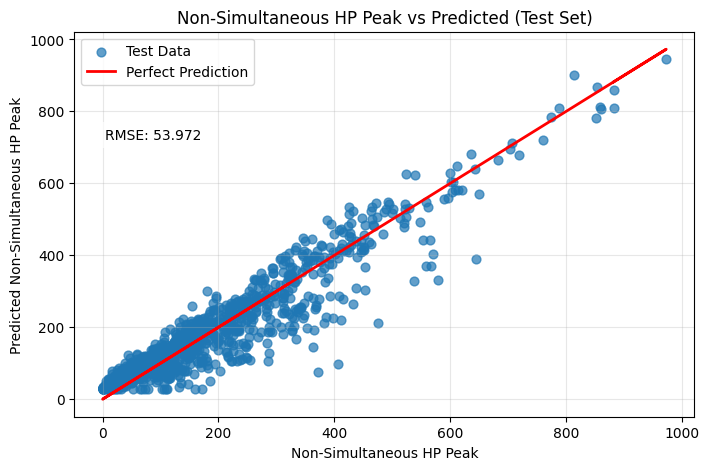

In [32]:
data_test = piece_lin_coeff_test_df[['HP_Sensitivity']].join(substations_df_test[['HP_Peak']], how='inner')

nonSimTestPred = nonSimDeltaFit.predict(data_test[['HP_Sensitivity']])
r2_nonSimTest = r2_score(data_test['HP_Peak'], nonSimTestPred)
print(f"R² for HP_Sensitivity vs Non-Simultaneous HP Peak on test set: {r2_nonSimTest:.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Sensitivity'], data_test['HP_Peak'], alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Sensitivity'], nonSimTestPred, color='red', linewidth=2, label=f'Linear Fit: y = {nonSimDeltaFit.coef_[0]:.3f}x + {nonSimDeltaFit.intercept_:.3f} (R²={r2_nonSimTest:.3f})')
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous HP Peak (Test Set)')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(data_test['HP_Peak'], nonSimTestPred, alpha=0.7, s=40, label='Test Data')
plt.plot(data_test['HP_Peak'], data_test['HP_Peak'], color='red', linewidth=2, label='Perfect Prediction')
plt.xlabel('Non-Simultaneous HP Peak')
plt.ylabel('Predicted Non-Simultaneous HP Peak')
plt.title('Non-Simultaneous HP Peak vs Predicted (Test Set)')
plt.text(0.05, 0.75, f'RMSE: {np.sqrt(mean_squared_error(data_test["HP_Peak"], nonSimTestPred)):.3f}', transform=plt.gca().transAxes, fontsize=10, va='top', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
plt.grid(alpha=0.3)
plt.legend()
plt.show()

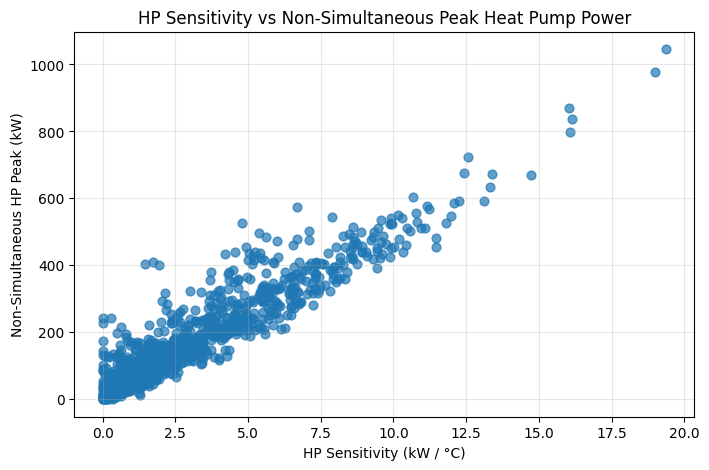

In [33]:
data_plot = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner')

plt.figure(figsize=(8, 5))
plt.scatter(data_plot['HP_Sensitivity'], data_plot['HP_Peak'], alpha=0.7, s=40)
plt.xlabel('HP Sensitivity (kW / °C)')
plt.ylabel('Non-Simultaneous HP Peak (kW)')
plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
plt.grid(alpha=0.3)
plt.show()

Training R² (weighted): 0.915
Test R²: 0.881
Test RMSE: 55.487 kW
Test MAPE: 28.91%
Linear model: HP_Peak = 48.923 * HP_Sensitivity + 12.784


c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


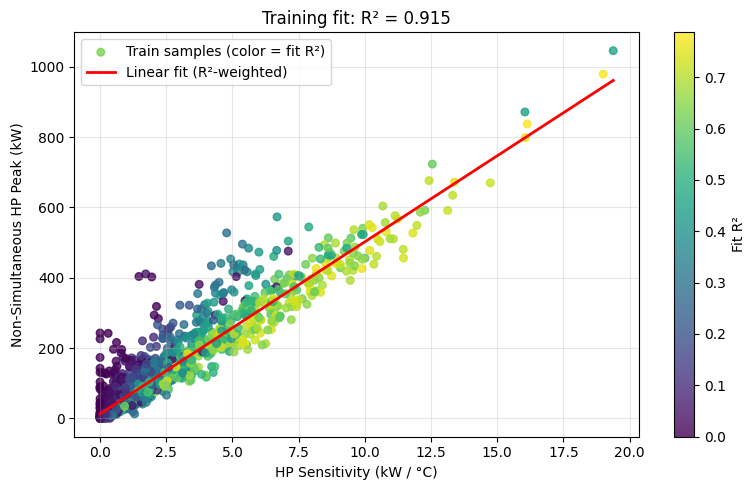

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


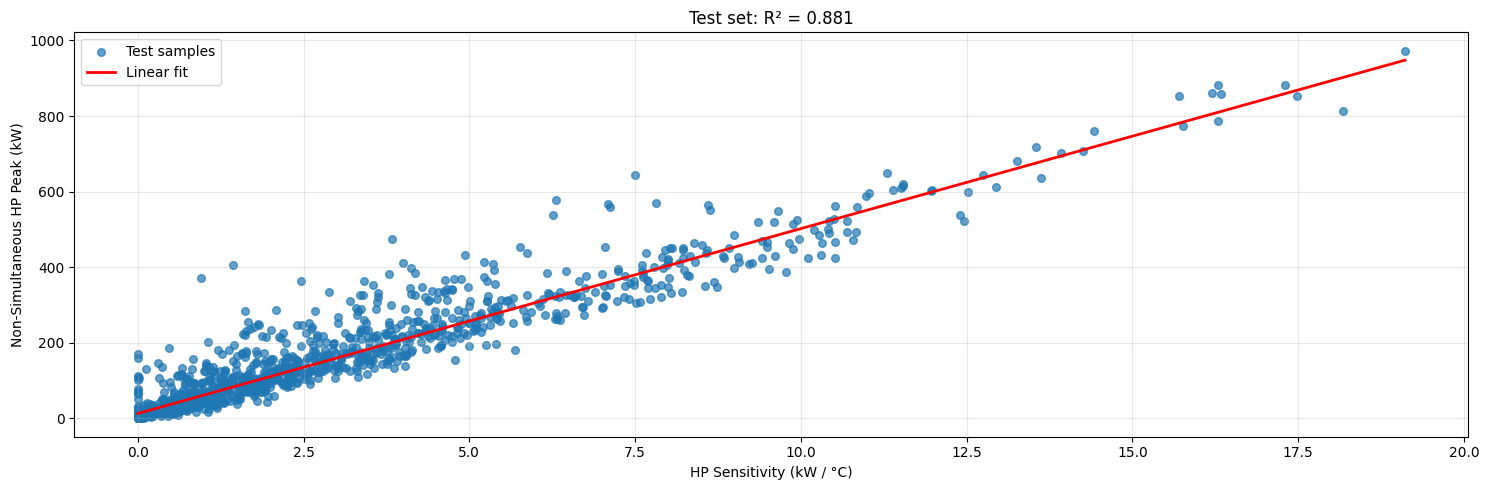

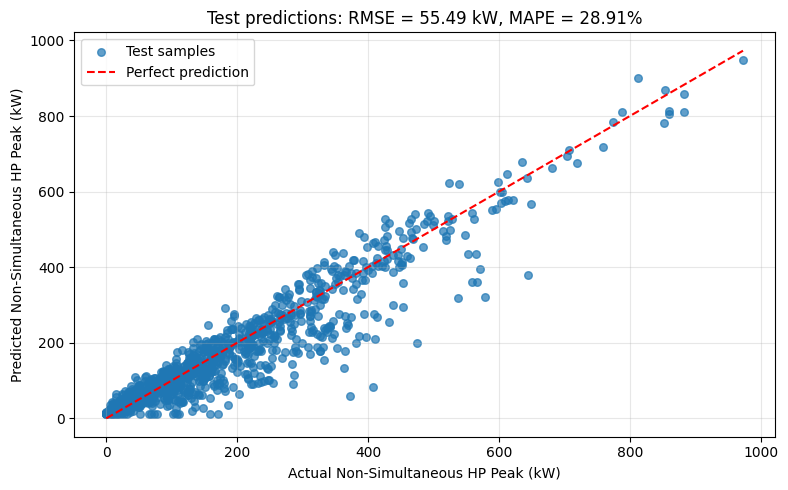

In [34]:
train_data = piece_lin_coeff_train_df[['HP_Sensitivity']].join(substations_df_train['HP_Peak'], how='inner').join(r2_score_train_df, how='inner').dropna()

# FIX: weight samples by fit quality (R²) instead of using a hard
# accept/reject threshold -- substations with a noisy/uncertain
# hockey-stick fit contribute less to the regression rather than being
# discarded outright.
sample_weight_train = train_data['R2_Score'].clip(0, 1)

modelLinSlope = LinearRegression()
modelLinSlope.fit(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)

test_data = piece_lin_coeff_test_df[['HP_Sensitivity']].join(substations_df_test['HP_Peak'], how='inner').dropna()
test_data['Predicted_HP_Peak'] = modelLinSlope.predict(test_data[['HP_Sensitivity']])

r2_train = modelLinSlope.score(train_data[['HP_Sensitivity']], train_data['HP_Peak'], sample_weight=sample_weight_train)
r2_test = r2_score(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
rmse_test = root_mean_squared_error(test_data['HP_Peak'], test_data['Predicted_HP_Peak'])
small_y_threshold = 10.0
mask = test_data['HP_Peak'].abs() > small_y_threshold
mape_test = mean_absolute_percentage_error(
    test_data.loc[mask, 'HP_Peak'],
    test_data.loc[mask, 'Predicted_HP_Peak']
) * 100

print(f"Training R² (weighted): {r2_train:.3f}")
print(f"Test R²: {r2_test:.3f}")
print(f"Test RMSE: {rmse_test:.3f} kW")
print(f"Test MAPE: {mape_test:.2f}%")
print(f"Linear model: HP_Peak = {modelLinSlope.coef_[0]:.3f} * HP_Sensitivity + {modelLinSlope.intercept_:.3f}")

# Plot training set, colored by fit R² (the sample weight)
fig_train, ax_train = plt.subplots(figsize=(8, 5))
sc = ax_train.scatter(train_data['HP_Sensitivity'], train_data['HP_Peak'], c=sample_weight_train, cmap='viridis', alpha=0.8, s=30, label='Train samples (color = fit R²)')
x_line = np.linspace(train_data['HP_Sensitivity'].min(), train_data['HP_Sensitivity'].max(), 100)
ax_train.plot(x_line, modelLinSlope.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit (R²-weighted)')
ax_train.set_xlabel('HP Sensitivity (kW / °C)')
ax_train.set_ylabel('Non-Simultaneous HP Peak (kW)')
ax_train.set_title(f'Training fit: R² = {r2_train:.3f}')
ax_train.grid(alpha=0.3)
ax_train.legend()
fig_train.colorbar(sc, ax=ax_train, label='Fit R²')
fig_train.tight_layout()
plt.show()

fig, axs = plt.subplots(figsize=(15, 5))
axs.scatter(test_data['HP_Sensitivity'], test_data['HP_Peak'], alpha=0.7, s=30, label='Test samples')
x_line = np.linspace(test_data['HP_Sensitivity'].min(), test_data['HP_Sensitivity'].max(), 100)
axs.plot(x_line, modelLinSlope.predict(x_line.reshape(-1, 1)), color='red', linewidth=2, label='Linear fit')
axs.set_xlabel('HP Sensitivity (kW / °C)')
axs.set_ylabel('Non-Simultaneous HP Peak (kW)')
axs.set_title(f'Test set: R² = {r2_test:.3f}')
axs.grid(alpha=0.3)
axs.legend()
fig.tight_layout()
plt.show()

# Plot test set predictions vs actual
min_val = min(test_data['HP_Peak'].min(), test_data['Predicted_HP_Peak'].min())
max_val = max(test_data['HP_Peak'].max(), test_data['Predicted_HP_Peak'].max())

fig_test, ax_test = plt.subplots(figsize=(8, 5))
ax_test.scatter(test_data['HP_Peak'], test_data['Predicted_HP_Peak'], alpha=0.7, s=30, label='Test samples')
ax_test.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')
ax_test.set_xlabel('Actual Non-Simultaneous HP Peak (kW)')
ax_test.set_ylabel('Predicted Non-Simultaneous HP Peak (kW)')
ax_test.set_title(f'Test predictions: RMSE = {rmse_test:.2f} kW, MAPE = {mape_test:.2f}%')
ax_test.grid(alpha=0.3)
ax_test.legend()
fig_test.tight_layout()
plt.show()

### Fit piecewise function to time-of-day indexed data

In [35]:
# FIX: previously fit 24 separate unconstrained 2-segment pwlf models per
# substation (one per hour), producing 120 often-noisy coefficients and
# visibly degenerate fits (S1 < -1000 outliers, see the diagnostic below).
# Instead, pool hours into 4 broader time-of-day windows and fit the same
# constrained hockey-stick model used for the daily fit above.
hour_groups = {
    'Night':     list(range(0, 6)),
    'Morning':   list(range(6, 12)),
    'Afternoon': list(range(12, 18)),
    'Evening':   list(range(18, 24)),
}

piece_lin_coeff_hourly = {}
r2_score_hourly = {}

for id in tqdm(substations_df_train.index, desc='Fitting hockey-stick model by time-of-day window'):
    try:
        temp_h = substations_df_train.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_train.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hourly[id] = {}
        r2_score_hourly[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x = group_data['Temperature'].values
            y = group_data['Total_Load'].values

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
            except Exception:
                continue

            piece_lin_coeff_hourly[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hourly[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            piece_lin_coeff_hourly[id][f'{group_name}_TBalance'] = T_balance
            r2_score_hourly[id][group_name] = r2

    except Exception:
        pass

Fitting hockey-stick model by time-of-day window: 100%|██████████| 1000/1000 [00:19<00:00, 52.15it/s]


In [36]:
piece_lin_coeff_hourly_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly, orient='index')
piece_lin_coeff_hourly_df.index.name = 'Substation_ID'

r2_score_hourly_df = pd.DataFrame.from_dict(r2_score_hourly, orient='index')
r2_score_hourly_df.index.name = 'Substation_ID'

sensitivity_cols = [c for c in piece_lin_coeff_hourly_df.columns if c.endswith('_Sensitivity')]

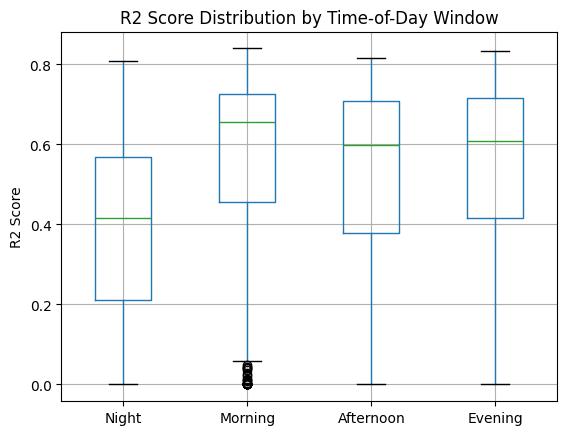

In [37]:
r2_score_hourly_df.boxplot()
plt.title('R2 Score Distribution by Time-of-Day Window')
plt.ylabel('R2 Score')
plt.show()

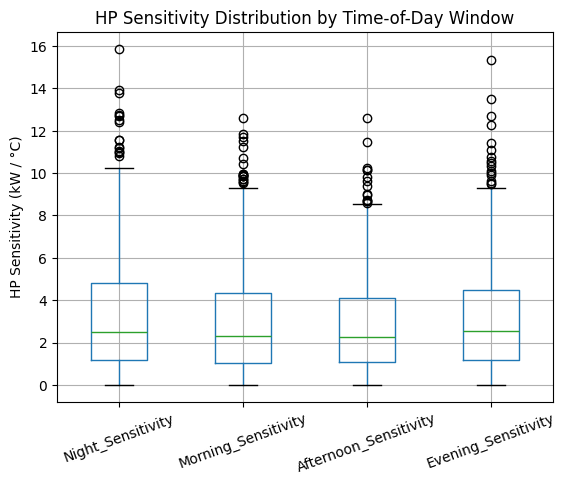

In [38]:
piece_lin_coeff_hourly_df[sensitivity_cols].boxplot()
plt.title('HP Sensitivity Distribution by Time-of-Day Window')
plt.ylabel('HP Sensitivity (kW / °C)')
plt.xticks(rotation=20)
plt.show()

In [39]:
# sensitivity_cols already isolated in cell 46; kept here under the
# original variable name for continuity with anything downstream.
piece_lin_coeff_hourly_df_s1 = piece_lin_coeff_hourly_df[sensitivity_cols]
piece_lin_coeff_hourly_df_s1.head()

,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
Substation_ID,,,,
440,1.759247,1.756669,1.662474,1.818981
573,2.359039,2.425002,2.388925,2.906608
946,2.452844,2.444169,2.725074,2.488282
997,2.059330,2.376420,2.509555,3.020763
503,4.672633,5.100222,4.502241,5.654743


In [42]:
# Correlation of each time-window's HP sensitivity with HP_Peak.
combined_df = piece_lin_coeff_hourly_df[sensitivity_cols].join(substations_df_train['HP_Peak'])

correlation_matrix = combined_df.corr()
hp_peak_correlations = correlation_matrix['HP_Peak'].drop('HP_Peak')

print("Correlation of time-window HP Sensitivity with HP_Peak:")
display(hp_peak_correlations.to_frame().T.style.background_gradient(cmap='RdYlGn', axis=1))

Correlation of time-window HP Sensitivity with HP_Peak:


,Night_Sensitivity,Morning_Sensitivity,Afternoon_Sensitivity,Evening_Sensitivity
HP_Peak,0.953617,0.958553,0.964889,0.967012


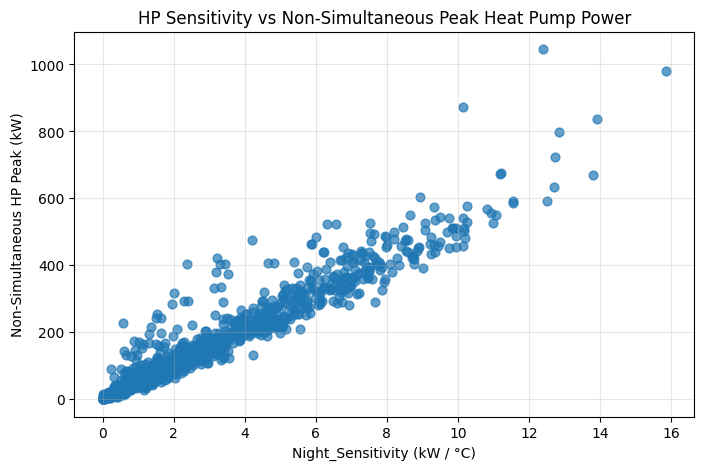

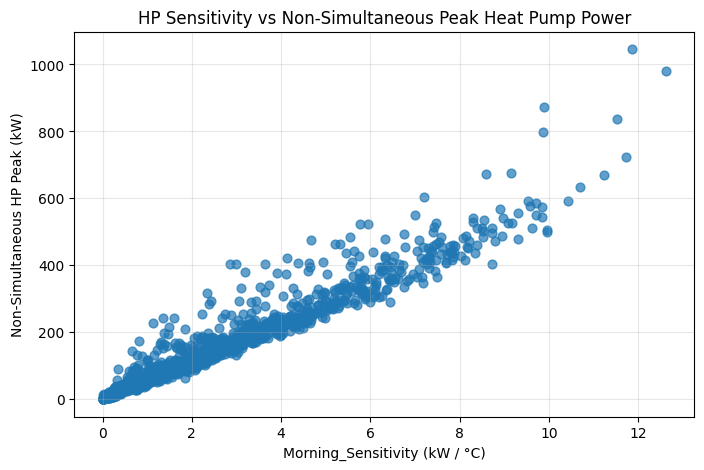

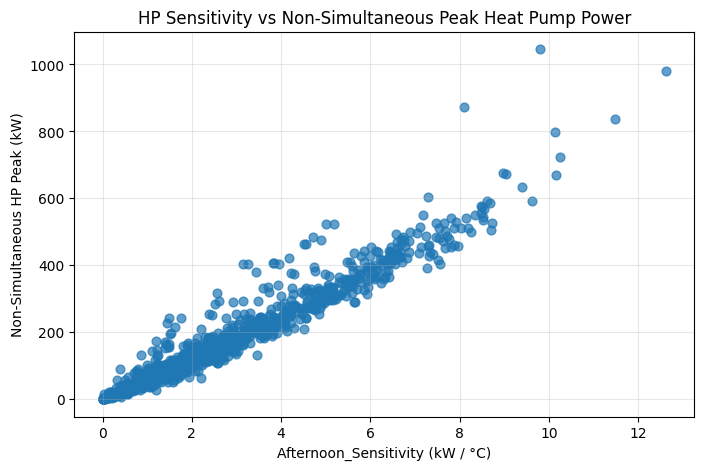

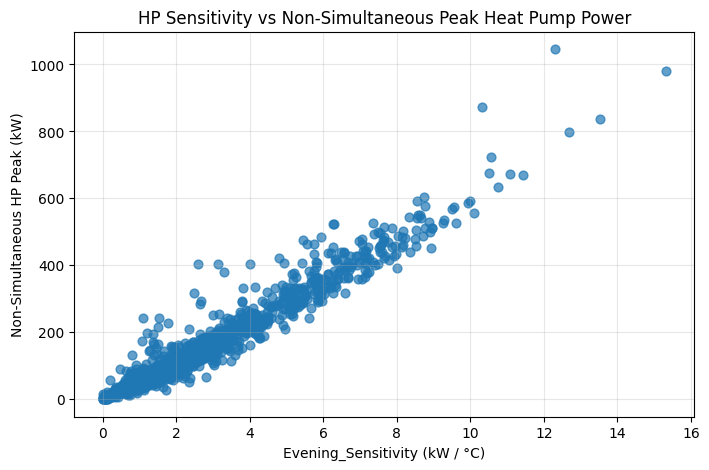

In [116]:
for col in sensitivity_cols:
    plt.figure(figsize=(8, 5))
    plt.scatter(combined_df[col], combined_df['HP_Peak'], alpha=0.7, s=40)
    plt.xlabel(f'{col} (kW / °C)')
    plt.ylabel('Non-Simultaneous HP Peak (kW)')
    plt.title('HP Sensitivity vs Non-Simultaneous Peak Heat Pump Power')
    plt.grid(alpha=0.3)
    plt.show()

In [117]:
piece_lin_coeff_hourly_test = {}
r2_score_hourly_test = {}

for id in tqdm(substations_df_test.index, desc='Fitting hockey-stick model by time-of-day window'):
    try:
        temp_h = substations_df_test.loc[id, 'Temperature'].resample('h').mean()
        load_h = substations_df_test.loc[id, 'Total_Load'].resample('h').mean()

        sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

        piece_lin_coeff_hourly_test[id] = {}
        r2_score_hourly_test[id] = {}

        for group_name, hours in hour_groups.items():
            group_data = sm_data[sm_data.index.hour.isin(hours)]

            x = group_data['Temperature'].values
            y = group_data['Total_Load'].values

            if len(x) < MIN_HEATING_DAYS:
                continue

            try:
                base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
            except Exception:
                continue

            piece_lin_coeff_hourly_test[id][f'{group_name}_BaseLoad'] = base_load
            piece_lin_coeff_hourly_test[id][f'{group_name}_Sensitivity'] = hp_sensitivity
            piece_lin_coeff_hourly_test[id][f'{group_name}_TBalance'] = T_balance
            r2_score_hourly_test[id][group_name] = r2

    except Exception:
        pass

Fitting hockey-stick model by time-of-day window: 100%|██████████| 1000/1000 [00:14<00:00, 69.21it/s]


In [118]:
piece_lin_coeff_hourly_test_df = pd.DataFrame.from_dict(piece_lin_coeff_hourly_test, orient='index')
piece_lin_coeff_hourly_test_df.index.name = 'Substation_ID'

r2_score_hourly_test_df = pd.DataFrame.from_dict(r2_score_hourly_test, orient='index')
r2_score_hourly_test_df.index.name = 'Substation_ID'

In [119]:
combined_test_df = piece_lin_coeff_hourly_test_df[sensitivity_cols].join(substations_df_test['HP_Peak'])

Selected Ridge alpha: 19.3070


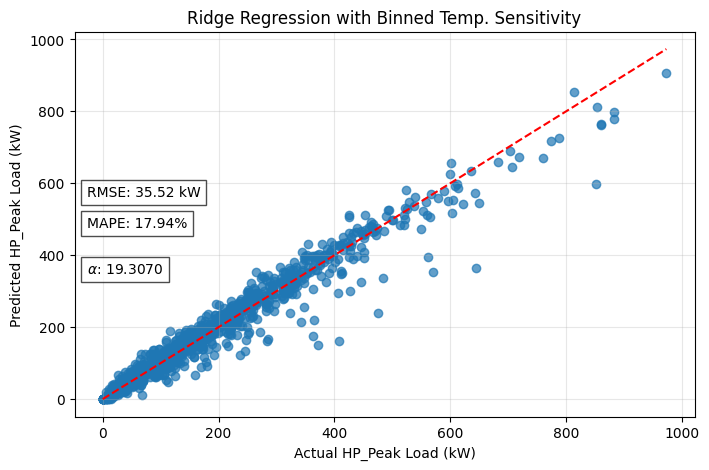

In [135]:
sensitivity_model = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
sensitivity_model.fit(combined_df[sensitivity_cols], combined_df['HP_Peak'])
print(f"Selected Ridge alpha: {sensitivity_model.alpha_:.4f}")

sensitivity_pred = sensitivity_model.predict(combined_test_df[sensitivity_cols])
sensitivity_pred = np.maximum(sensitivity_pred, 0) # ensure no negative predictions

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(combined_test_df['HP_Peak'], sensitivity_pred, alpha=0.7)
ax.plot([0, combined_test_df['HP_Peak'].max()], [0, combined_test_df['HP_Peak'].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Ridge Regression with Binned Temp. Sensitivity')
mask = combined_test_df['HP_Peak'].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(combined_test_df['HP_Peak'].values[mask], sensitivity_pred[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(combined_test_df['HP_Peak'].values, sensitivity_pred)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {sensitivity_model.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.grid(alpha=0.3)
plt.show()

## Baseline (Peak Net Load = Simultaneous HP Peak Load)

In [46]:
# baseline_pred = X_test['Feature_Max_Max']
# col = 'HP_Peak'

# fig, ax = plt.subplots()
# ax.scatter(y_test[substations_df_test['size'] < 33][col], baseline_pred[substations_df_test['size'] < 33], alpha=0.7)
# ax.scatter(y_test[(substations_df_test['size'] >= 33) & (substations_df_test['size'] < 66)][col], baseline_pred[(substations_df_test['size'] >= 33) & (substations_df_test['size'] < 66)], alpha=0.7)
# ax.scatter(y_test[(substations_df_test['size'] >= 66) & (substations_df_test['size'] < 100)][col], baseline_pred[(substations_df_test['size'] >= 66) & (substations_df_test['size'] < 100)], alpha=0.7)
# ax.plot([y_test[col].min(), y_test[col].max()], [y_test[col].min(), y_test[col].max()], 'r--')
# ax.set_xlabel(f'Actual {col} Load (kW)')
# ax.set_ylabel(f'Predicted {col} Load (kW)')
# ax.set_title(f'Actual vs Baseline {col}')
# mape = mean_absolute_percentage_error(y_test[col].values, baseline_pred) * 100
# rmse = root_mean_squared_error(y_test[col].values, baseline_pred)
# ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
# plt.legend(['Size < 33', '33 <= Size < 66', '66 <= Size < 100', 'Ideal Prediction'])
# plt.show()

## Time Based Features

In [86]:
substations_time = {}

resolution = 15  # in minutes
T_base = 12.0  # degC, balance temperature for heating degree hours (HDH)

for i in trange(len(substations_df), desc='Extracting time-based features for substations'):

    sub_df = substations_df.iloc[i]['Total_Load'].resample(f'{resolution}min').mean().ffill()
    sub_df = sub_df[sub_df.index.weekday < 5]  # Keep only weekdays
    weather_df = substations_df.iloc[i]['Temperature'].resample(f'{resolution}min').mean().ffill()
    weather_df = weather_df[weather_df.index.weekday < 5]  # Keep only weekdays

    loadDict = {
        'Total_Load': sub_df.values,
        'Date': sub_df.index.date,
        'Time': sub_df.index.time
    }

    weatherDict = {
        'Temperature': weather_df.values,
        'Date': weather_df.index.date,
        'Time': weather_df.index.time
    }

    loadDf = pd.DataFrame(loadDict, columns=['Total_Load', 'Date', 'Time'])

    weather_data = pd.DataFrame(weatherDict, columns=['Temperature', 'Date', 'Time'])

    dailyLoad = loadDf.pivot(index='Date', columns='Time', values='Total_Load').ffill()
    dailyWeather = weather_data.pivot(index='Date', columns='Time', values='Temperature').ffill()
    dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

    # ADD: heating degree hours, same shape as dailyWeather
    hdh = np.maximum(0, T_base - dailyWeather)

    dailyFeatures = {}
    dailyFeatures['Mean'] = dailyLoad.mean(axis=0)
    dailyFeatures['Std'] = dailyLoad.std(axis=0)
    dailyFeatures['Min'] = dailyLoad.min(axis=0)
    dailyFeatures['Max'] = dailyLoad.max(axis=0)
    dailyFeatures['Skew'] = dailyLoad.skew(axis=0)
    dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=0)
    dailyFeatures['Max-Min'] = dailyLoad.max(axis=0) - dailyLoad.min(axis=0)
    dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[:,i], dailyWeather.iloc[:,i])[0][1]
                                            for i in range(dailyLoad.shape[1])])
    dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=0).statistic
    # ADD: correlation against HDH instead of raw temperature — always
    # non-negative for HP-driven load, avoids the summer cooling sign flip,
    # and connects directly to the HDD-normalization framework.
    dailyFeatures['Corr_HDH'] = pearsonr(x=dailyLoad, y=hdh, axis=0).statistic

    dailyFeaturesDf = pd.DataFrame(dailyFeatures)

    substations_time[i] = {}

    for key_main in dailyFeaturesDf.keys():
        for key_sub in dailyFeaturesDf.index:
            substations_time[i][f'Feature {key_main}_{key_sub}'] = dailyFeaturesDf[key_main][key_sub]

substations_time_df = pd.DataFrame.from_dict(substations_time, orient='index')
pickle.dump(substations_time_df, open('data/substations_time_data.pkl', 'wb'))

Extracting time-based features for substations: 100%|██████████| 2000/2000 [01:33<00:00, 21.50it/s]


In [87]:
substations_time_df = pickle.load(open('data/substations_time_data.pkl', 'rb'))

# FIX: fillna(0) is wrong for Corr_Pearson/Corr_HDH columns -- 0 means "no
# correlation", not "missing data". Use the column median for correlation
# features and 0 only for magnitude features.
corr_cols = [c for c in substations_time_df.columns if 'Corr' in c]
other_cols = [c for c in substations_time_df.columns if c not in corr_cols]

substations_time_df[corr_cols] = substations_time_df[corr_cols].apply(lambda col: col.fillna(col.median()))
substations_time_df[other_cols] = substations_time_df[other_cols].fillna(0)

substations_time_df['HP_Peak'] = substations_df['HP_Peak'].copy()

# ADD: per-household normalized magnitude features. Mean/Std/Min/Max/
# Max-Min/Cov all scale with the number of households in the substation;
# dividing by size removes that confound so the 864 raw features and their
# per-household counterparts both reach the model, and it can use whichever
# is more informative for a given time slot.
peak_load = [substations_df['Total_Load'].iloc[i].max() for i in range(len(substations_df))]
magnitude_keys = ['Mean', 'Std', 'Min', 'Max', 'Max-Min', 'Cov']

for col in list(substations_time_df.columns):
    if col == 'HP_Peak':
        continue
    if any(col.startswith(f'Feature {k}_') for k in magnitude_keys):
        substations_time_df[f'{col}_per_hh'] = (substations_time_df[col] / np.array(peak_load)).copy()

substations_time_df_train, substations_time_df_test = train_test_split(substations_time_df, test_size=0.5, random_state=42)

X_train_time = substations_time_df_train.drop(columns=['HP_Peak'])
y_train_time = substations_time_df_train[['HP_Peak']]

X_test_time = substations_time_df_test.drop(columns=['HP_Peak'])
y_test_time = substations_time_df_test[['HP_Peak']]

C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_27428\2968069573.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  substations_time_df['HP_Peak'] = substations_df['HP_Peak'].copy()
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_27428\2968069573.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  substations_time_df[f'{col}_per_hh'] = (substations_time_df[col] / np.array(peak_load)).copy()
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_27428\2968069573.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually

In [88]:
def objectiveMC(space):
    X_tr, X_val, y_tr, y_val = train_test_split(X_train_time, y_train_time, test_size=0.2, random_state=42)

    reg = xgb.XGBRegressor(
        learning_rate=space['eta'],
        n_estimators=int(space['n_estimators']),
        max_depth=int(space['max_depth']),
        gamma=space['gamma'],
        subsample=space['subsample'],
        reg_alpha=space['reg_alpha'],
        reg_lambda=space['reg_lambda'],
        min_child_weight=int(space['min_child_weight']),
        colsample_bytree=space['colsample_bytree'],
        eval_metric="mae",
        tree_method='hist',       # faster histogram-based splits
        early_stopping_rounds=20, # stop once validation stops improving
        n_jobs=-1,
    )
    reg.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    pred = reg.predict(X_val)
    loss = mean_squared_error(y_val, pred)
    
    return {'loss': loss, 'status': STATUS_OK }
    

def tune_and_train_xgb(XIrrTrain_MC, yIrrTrain_MC):
    space = {
    'eta': hp.uniform('eta', 0.01, 0.3),
    'max_depth': hp.quniform("max_depth", 3, 10, 1),
    'gamma': hp.uniform('gamma', 0, 10),
    'subsample': hp.uniform('subsample', 0.5, 1),
    'reg_alpha': hp.uniform('reg_alpha', 0, 1),
    'reg_lambda': hp.uniform('reg_lambda', 0, 10),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.3, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 20, 1),
    'n_estimators': hp.quniform('n_estimators', 50, 500, 10),
}

    trials = Trials()

    start_time_ht = time.time()
    best_hyperparams_MC = fmin(fn = objectiveMC,
                            space = space,
                            algo = tpe.suggest,
                            max_evals = 150,
                            trials = trials,
                            early_stop_fn=no_progress_loss(30),
                            )
    end_time_ht = time.time()
    print("Hyperparameter tuning took " + str(end_time_ht - start_time_ht) + " seconds")

    xgb_model_MC = xgb.XGBRegressor(
        learning_rate=best_hyperparams_MC['eta'],
        n_estimators=int(best_hyperparams_MC['n_estimators']),
        max_depth=int(best_hyperparams_MC['max_depth']),
        gamma=best_hyperparams_MC['gamma'],
        subsample=best_hyperparams_MC['subsample'],
        reg_alpha=best_hyperparams_MC['reg_alpha'],
        reg_lambda=best_hyperparams_MC['reg_lambda'],
        min_child_weight=int(best_hyperparams_MC['min_child_weight']),
        colsample_bytree=best_hyperparams_MC['colsample_bytree'],
        eval_metric="mae"
    )

    start_time_fit = time.time()
    xgb_model_MC.fit(XIrrTrain_MC, yIrrTrain_MC)
    end_time_fit = time.time()
    
    print("Fitting took " + str(end_time_fit - start_time_fit) + " seconds")
    return xgb_model_MC, best_hyperparams_MC

 35%|███▍      | 52/150 [04:22<08:14,  5.04s/trial, best loss: 170.99025664483443]
Hyperparameter tuning took 262.2108769416809 seconds
Fitting took 4.332073211669922 seconds
Best hyperparameters: {'colsample_bytree': 0.7741827510808226, 'eta': 0.06695363100327892, 'gamma': 7.928077587870846, 'max_depth': 4.0, 'min_child_weight': 1.0, 'n_estimators': 210.0, 'reg_alpha': 0.9630882638395075, 'reg_lambda': 9.860370689240067, 'subsample': 0.996372617808148}


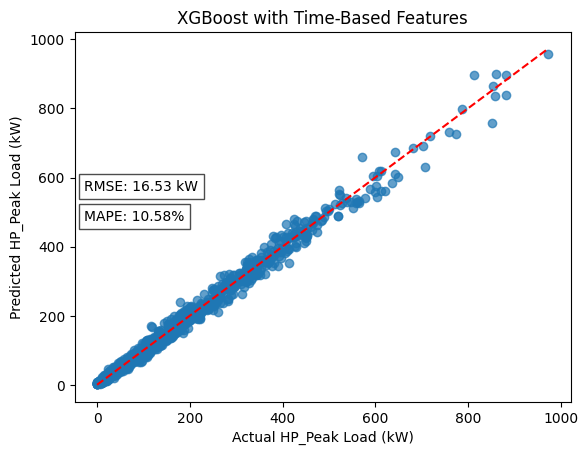

In [89]:
col = 'HP_Peak'

if retrain_xgb_time or not os.path.exists('models/xgb_time_model.pkl') or not os.path.exists('models/xgb_time_hyperparams.pkl'):
    xgb_time_model, xgb_time_best_hyperparams = tune_and_train_xgb(X_train_time, y_train_time[col])
    print("Best hyperparameters:", xgb_time_best_hyperparams)
    pickle.dump(xgb_time_model, open('models/xgb_time_model.pkl', 'wb'))
    pickle.dump(xgb_time_best_hyperparams, open('models/xgb_time_hyperparams.pkl', 'wb'))
else:
    xgb_time_model = pickle.load(open('models/xgb_time_model.pkl', 'rb'))
    xgb_time_best_hyperparams = pickle.load(open('models/xgb_time_hyperparams.pkl', 'rb'))
    print("Loaded XGBoost model with hyperparameters:", xgb_time_best_hyperparams)

xgb_pred_time = xgb_time_model.predict(X_test_time)
xgb_pred_time = np.maximum(xgb_pred_time, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time[col], xgb_pred_time, alpha=0.7)
ax.plot([y_test_time[col].min(), y_test_time[col].max()], [y_test_time[col].min(), y_test_time[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'XGBoost with Time-Based Features')
mask = y_test_time[col].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_time[col].values[mask], xgb_pred_time[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_time[col].values, xgb_pred_time)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

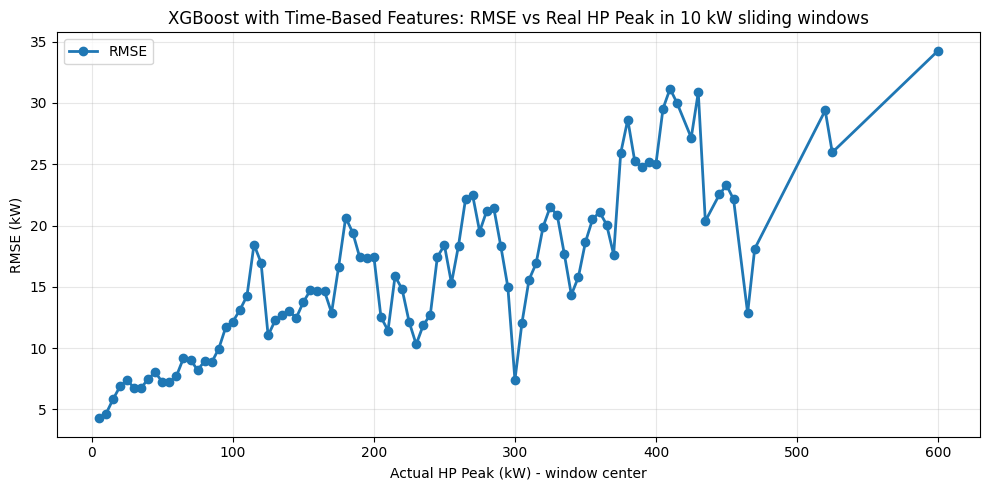

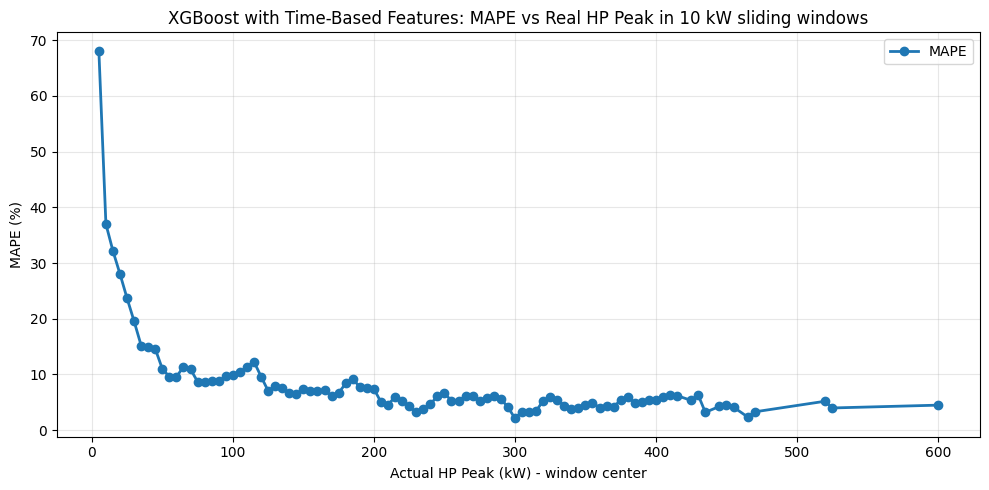

In [90]:
# Actual HP peak values from the test set
y_true = y_test_time['HP_Peak'].to_numpy()

# Predictions from the existing XGBoost model (cell 74)
y_pred = np.asarray(xgb_pred_time).reshape(-1)

# RMSE in rolling/sliding windows of 10 kW on the actual HP values
window_kW = 10.0
step_kW = 5.0  # 50% overlap between consecutive windows

min_val = np.floor(y_true.min() / window_kW) * window_kW
max_val = np.ceil(y_true.max() / window_kW) * window_kW

centers = np.arange(min_val + window_kW / 2, max_val, step_kW)
rmse_vals = []
counts = []

for c in centers:
    mask = (y_true >= c - window_kW / 2) & (y_true < c + window_kW / 2)
    n = int(mask.sum())
    counts.append(n)

    if n < 5:
        rmse_vals.append(np.nan)
    else:
        err = y_true[mask] - y_pred[mask]
        rmse_vals.append(np.sqrt(np.mean(err**2)))

centers = np.asarray(centers)
rmse_vals = np.asarray(rmse_vals)
counts = np.asarray(counts)

nonzero_mask = y_true != 0
mape_nonzero = mean_absolute_percentage_error(y_true[nonzero_mask], y_pred[nonzero_mask]) * 100

plt.figure(figsize=(10, 5))
valid = np.isfinite(rmse_vals)
plt.plot(centers[valid], rmse_vals[valid], marker='o', linewidth=2, label='RMSE')
plt.xlabel('Actual HP Peak (kW) - window center')
plt.ylabel('RMSE (kW)')
plt.title(f'XGBoost with Time-Based Features: RMSE vs Real HP Peak in 10 kW sliding windows')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
mape_vals = []

for c in centers:
    window_mask = (y_true >= c - window_kW / 2) & (y_true < c + window_kW / 2) & (y_true != 0)
    if int(window_mask.sum()) < 5:
        mape_vals.append(np.nan)
    else:
        err_pct = np.abs((y_true[window_mask] - y_pred[window_mask]) / y_true[window_mask]) * 100
        mape_vals.append(np.mean(err_pct))

mape_vals = np.asarray(mape_vals)

plt.figure(figsize=(10, 5))
valid_mape = np.isfinite(mape_vals)
plt.plot(centers[valid_mape], mape_vals[valid_mape], marker='o', linewidth=2, label='MAPE')
plt.xlabel('Actual HP Peak (kW) - window center')
plt.ylabel('MAPE (%)')
plt.title('XGBoost with Time-Based Features: MAPE vs Real HP Peak in 10 kW sliding windows')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


Selected Ridge alpha: 0.0518


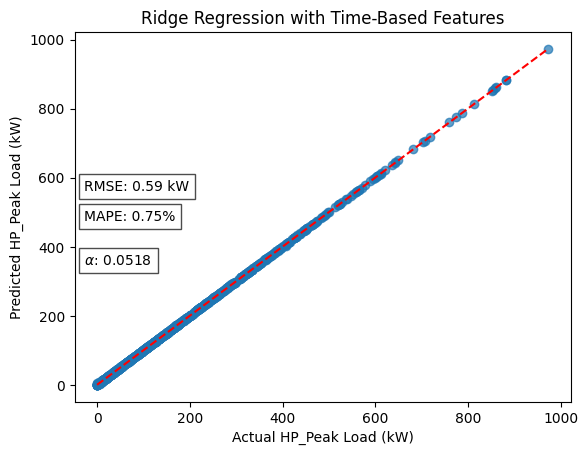

In [95]:
col = 'HP_Peak'

linreg_time_model = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
linreg_time_model.fit(X_train_time, y_train_time[col])
print(f"Selected Ridge alpha: {linreg_time_model.alpha_:.4f}")

linreg_pred_time = linreg_time_model.predict(X_test_time)
linreg_pred_time = np.maximum(linreg_pred_time, 0) # ensure no negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time[col], linreg_pred_time, alpha=0.7)
ax.plot([0, y_test_time[col].max()], [0, y_test_time[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Ridge Regression with Time-Based Features')
mask = y_test_time[col].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_time[col].values[mask], linreg_pred_time[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_time[col].values, linreg_pred_time)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {linreg_time_model.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

## Time-Based + Piecewise Linear Coefficients

In [92]:
substations_time_pwlf_train_df = substations_time_df_train.join(piece_lin_coeff_df, how='left')
substations_time_pwlf_test_df = substations_time_df_test.join(piece_lin_coeff_df, how='left')

In [93]:
X_train_time_pwlf = substations_time_pwlf_train_df.drop(columns=['HP_Peak'])
y_train_time_pwlf = substations_time_pwlf_train_df[['HP_Peak']]

X_test_time_pwlf = substations_time_pwlf_test_df.drop(columns=['HP_Peak'])
y_test_time_pwlf = substations_time_pwlf_test_df[['HP_Peak']]


  0%|          | 0/150 [00:00<?, ?trial/s, best loss=?]

 42%|████▏     | 63/150 [07:36<10:30,  7.24s/trial, best loss: 174.68291580418875]
Hyperparameter tuning took 456.413631439209 seconds
Fitting took 10.56852126121521 seconds
Best hyperparameters: {'colsample_bytree': 0.6596798267036718, 'eta': 0.09749218660235492, 'gamma': 7.960661685481312, 'max_depth': 4.0, 'min_child_weight': 5.0, 'n_estimators': 400.0, 'reg_alpha': 0.5840738490143904, 'reg_lambda': 2.936267653901922, 'subsample': 0.9874588699052179}


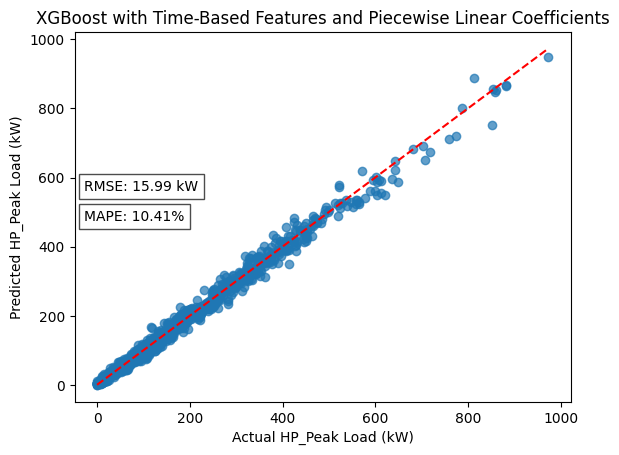

Selected Ridge alpha: 0.0518


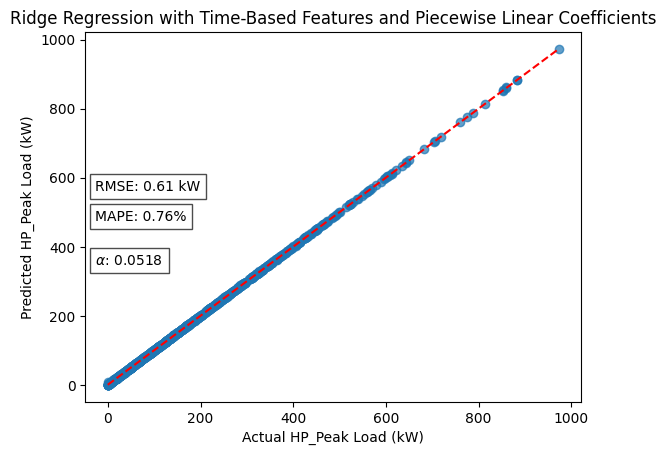

In [134]:
col = 'HP_Peak'

if retrain_xgb_time_pwlf or not os.path.exists('models/xgb_time_pwlf_model.pkl') or not os.path.exists('models/xgb_time_pwlf_hyperparams.pkl'):
    xgb_time_pwlf_model, xgb_time_pwlf_best_hyperparams = tune_and_train_xgb(X_train_time_pwlf, y_train_time_pwlf[col])
    print("Best hyperparameters:", xgb_time_pwlf_best_hyperparams)
    pickle.dump(xgb_time_pwlf_model, open('models/xgb_time_pwlf_model.pkl', 'wb'))
    pickle.dump(xgb_time_pwlf_best_hyperparams, open('models/xgb_time_pwlf_hyperparams.pkl', 'wb'))
else:
    xgb_time_pwlf_model = pickle.load(open('models/xgb_time_pwlf_model.pkl', 'rb'))
    xgb_time_pwlf_best_hyperparams = pickle.load(open('models/xgb_time_pwlf_hyperparams.pkl', 'rb'))


xgb_pred_time_pwlf = xgb_time_pwlf_model.predict(X_test_time_pwlf)
xgb_pred_time_pwlf = np.maximum(xgb_pred_time_pwlf, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time_pwlf[col], xgb_pred_time_pwlf, alpha=0.7)
ax.plot([y_test_time_pwlf[col].min(), y_test_time_pwlf[col].max()], [y_test_time_pwlf[col].min(), y_test_time_pwlf[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'XGBoost with Time-Based Features and Piecewise Linear Coefficients')
mask = y_test_time_pwlf[col].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_time_pwlf[col].values[mask], xgb_pred_time_pwlf[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_time_pwlf[col].values, xgb_pred_time_pwlf)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

linreg_time_pwlf_model = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)
linreg_time_pwlf_model.fit(X_train_time_pwlf, y_train_time_pwlf[col])
print(f"Selected Ridge alpha: {linreg_time_pwlf_model.alpha_:.4f}")
linreg_pred_time_pwlf = linreg_time_pwlf_model.predict(X_test_time_pwlf)
linreg_pred_time_pwlf = np.maximum(linreg_pred_time_pwlf, 0) # ensure no negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time_pwlf[col], linreg_pred_time_pwlf, alpha=0.7)
ax.plot([0, y_test_time_pwlf[col].max()], [0, y_test_time_pwlf[col].max()], 'r--')
ax.set_xlabel(f'Actual {col} Load (kW)')
ax.set_ylabel(f'Predicted {col} Load (kW)')
ax.set_title(f'Ridge Regression with Time-Based Features and Piecewise Linear Coefficients')
mask = y_test_time_pwlf[col].values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_time_pwlf[col].values[mask], linreg_pred_time_pwlf[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_time_pwlf[col].values, linreg_pred_time_pwlf)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {linreg_time_pwlf_model.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

## HDD Bins

In [169]:
# ============================================================
# Helper functions
# ============================================================

def assign_time_window(ts):
    """
    4 broad time windows:
      night   = 00:00-05:59
      morning = 06:00-09:59
      day     = 10:00-15:59
      evening = 16:00-23:59
    """
    h = ts.hour
    if 0 <= h < 6:
        return "night"
    elif 6 <= h < 10:
        return "morning"
    elif 10 <= h < 16:
        return "day"
    else:
        return "evening"


def assign_hdd_bin(severity, mild_thresh, cold_thresh):
    """
    Daily severity bins:
      warm    : severity == 0
      mild    : 0 < severity <= mild_thresh
      cold    : mild_thresh < severity <= cold_thresh
      extreme : severity > cold_thresh
    """
    if pd.isna(severity):
        return np.nan
    if severity <= 0:
        return "warm"
    elif severity <= mild_thresh:
        return "mild"
    elif severity <= cold_thresh:
        return "cold"
    else:
        return "extreme"


def safe_std(x):
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return np.nan
    return x.std(ddof=1)


def safe_skew(x):
    x = pd.Series(x).dropna()
    if len(x) < 3:
        return np.nan
    return x.skew()


def safe_kurtosis(x):
    x = pd.Series(x).dropna()
    if len(x) < 4:
        return np.nan
    return x.kurt()


def safe_quantile(x, q):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return np.nan
    return x.quantile(q)


def safe_cov(x, y):
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if len(x) < 2:
        return np.nan
    return np.cov(x, y, ddof=1)[0, 1]


def safe_corr(x, y):
    x = pd.Series(x)
    y = pd.Series(y)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    if len(x) < 3:
        return np.nan
    if x.std(ddof=1) == 0 or y.std(ddof=1) == 0:
        return np.nan
    return x.corr(y)


def add_distribution_features(feature_dict, prefix, values,
                              include_minmax=True,
                              include_shape=True,
                              include_quantiles=True):
    """
    Add statistical features for a vector of load values.
    """
    s = pd.Series(values).dropna()

    feature_dict[f"{prefix}_Mean"] = s.mean() if len(s) > 0 else np.nan
    feature_dict[f"{prefix}_Std"] = safe_std(s)

    if include_minmax:
        feature_dict[f"{prefix}_Min"] = s.min() if len(s) > 0 else np.nan
        feature_dict[f"{prefix}_Max"] = s.max() if len(s) > 0 else np.nan
        feature_dict[f"{prefix}_Max-Min"] = (s.max() - s.min()) if len(s) > 0 else np.nan

    if include_shape:
        feature_dict[f"{prefix}_Skew"] = safe_skew(s)
        feature_dict[f"{prefix}_Kurtosis"] = safe_kurtosis(s)

    if include_quantiles:
        feature_dict[f"{prefix}_Q50"] = safe_quantile(s, 0.50)
        feature_dict[f"{prefix}_Q95"] = safe_quantile(s, 0.95)

    feature_dict[f"{prefix}_N_obs"] = len(s)


# ============================================================
# Core function: one entity / one feeder / one substation
# ============================================================

def extract_windowed_hdd_features_from_series(
    load_series,
    temp_series,
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    weekday_only=True,
    window_order=None,
    bin_order=None,
    compare_pairs=None,
    stats_for_comparison=None,
    epsilon=1e-6,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=False,
    return_aligned=False,
):
    """
    Extract windowed HDD-binned features from one load series and one temperature series.

    Parameters
    ----------
    load_series : pd.Series
        Load time series with DatetimeIndex.
    temp_series : pd.Series
        Temperature time series with DatetimeIndex.
    resolution : int
        Resampling resolution in minutes.
    T_base : float
        Base temperature for HDH calculation.
    mild_thresh : float
        Daily HDH severity threshold for mild bin.
    cold_thresh : float
        Daily HDH severity threshold for cold bin.
    weekday_only : bool
        Whether to keep only weekdays.
    window_order : list
        Time windows to use.
    bin_order : list
        HDD bins to use.
    compare_pairs : list of tuple
        Bin pairs for comparative features.
    stats_for_comparison : list
        Which stats to compare across bins.
    epsilon : float
        Small number for ratio denominators.
    include_shape : bool
        Include skew / kurtosis.
    include_minmax : bool
        Include min / max / range.
    include_quantiles : bool
        Include Q50 / Q95.
    include_n_days : bool
        Include N_days per window-bin.
    include_corr_features : bool
        Include correlation/covariance with Temperature and HDH.
    include_climate_context : bool
        Include overall daily severity summary stats.
    normalize_by_peak : bool
        Add peak-normalized magnitude features.
    return_aligned : bool
        If True, also return the aligned timestamp-level dataframe.

    Returns
    -------
    feat : dict
        Feature dictionary for one entity.
    aligned : pd.DataFrame (optional)
        Intermediate aligned dataframe.
    """

    if window_order is None:
        window_order = ["night", "morning", "day", "evening"]

    if bin_order is None:
        bin_order = ["warm", "mild", "cold", "extreme"]

    if compare_pairs is None:
        compare_pairs = [
            ("mild", "warm"),
            ("cold", "warm"),
            ("extreme", "warm"),
            ("extreme", "cold"),
        ]

    if stats_for_comparison is None:
        stats_for_comparison = ["Mean", "Std", "Q50", "Q95", "Max"]

    # --------------------------------------------------------
    # 1) Basic checks
    # --------------------------------------------------------
    if not isinstance(load_series.index, pd.DatetimeIndex):
        raise ValueError("load_series must have a DatetimeIndex")
    if not isinstance(temp_series.index, pd.DatetimeIndex):
        raise ValueError("temp_series must have a DatetimeIndex")

    # --------------------------------------------------------
    # 2) Resample and align
    # --------------------------------------------------------
    load_series = load_series.resample(f"{resolution}min").mean().ffill()
    temp_series = temp_series.resample(f"{resolution}min").mean().ffill()

    if weekday_only:
        load_series = load_series[load_series.index.weekday < 5]
        temp_series = temp_series[temp_series.index.weekday < 5]

    aligned = pd.concat([load_series, temp_series], axis=1, join="inner")
    aligned.columns = ["Total_Load", "Temperature"]
    aligned = aligned.dropna()

    if aligned.empty:
        return ({}, aligned) if return_aligned else {}

    # --------------------------------------------------------
    # 3) Time features + HDH
    # --------------------------------------------------------
    aligned["Date"] = aligned.index.date
    aligned["Window"] = [assign_time_window(ts) for ts in aligned.index]

    aligned["HDH"] = np.maximum(T_base - aligned["Temperature"], 0.0)
    aligned["HDH_qh"] = aligned["HDH"] * (resolution / 60.0)

    daily_severity = aligned.groupby("Date")["HDH_qh"].sum().rename("Daily_HDH_Severity")
    aligned = aligned.join(daily_severity, on="Date")

    aligned["HDD_Bin"] = aligned["Daily_HDH_Severity"].apply(
        lambda x: assign_hdd_bin(x, mild_thresh=mild_thresh, cold_thresh=cold_thresh)
    )

    # --------------------------------------------------------
    # 4) Feature extraction
    # --------------------------------------------------------
    feat = {}

    if include_climate_context:
        feat["Feature Daily_HDH_Severity_Mean"] = daily_severity.mean()
        feat["Feature Daily_HDH_Severity_Std"] = daily_severity.std(ddof=1)
        feat["Feature Daily_HDH_Severity_Max"] = daily_severity.max()
        feat["Feature N_weekdays"] = aligned["Date"].nunique()

    # Per window × HDD bin features
    for window in window_order:
        for hdd_bin in bin_order:
            mask = (aligned["Window"] == window) & (aligned["HDD_Bin"] == hdd_bin)

            load_vals = aligned.loc[mask, "Total_Load"]
            temp_vals = aligned.loc[mask, "Temperature"]
            hdh_vals = aligned.loc[mask, "HDH"]
            n_days = aligned.loc[mask, "Date"].nunique()

            prefix = f"Feature {window}_{hdd_bin}"

            add_distribution_features(
                feat,
                prefix,
                load_vals,
                include_minmax=include_minmax,
                include_shape=include_shape,
                include_quantiles=include_quantiles,
            )

            if include_n_days:
                feat[f"{prefix}_N_days"] = n_days

            if include_corr_features:
                feat[f"{prefix}_Cov_Temp"] = safe_cov(load_vals, temp_vals)
                feat[f"{prefix}_Corr_Temp"] = safe_corr(load_vals, temp_vals)
                feat[f"{prefix}_Cov_HDH"] = safe_cov(load_vals, hdh_vals)
                feat[f"{prefix}_Corr_HDH"] = safe_corr(load_vals, hdh_vals)

    # --------------------------------------------------------
    # 5) Comparative features across bins (within each window)
    # --------------------------------------------------------
    for window in window_order:
        for high_bin, low_bin in compare_pairs:
            for stat in stats_for_comparison:
                high_key = f"Feature {window}_{high_bin}_{stat}"
                low_key = f"Feature {window}_{low_bin}_{stat}"

                high_val = feat.get(high_key, np.nan)
                low_val = feat.get(low_key, np.nan)

                feat[f"Feature {window}_delta_{stat}_{high_bin}_{low_bin}"] = (
                    high_val - low_val
                    if pd.notna(high_val) and pd.notna(low_val)
                    else np.nan
                )

                feat[f"Feature {window}_ratio_{stat}_{high_bin}_{low_bin}"] = (
                    high_val / (low_val + epsilon)
                    if pd.notna(high_val) and pd.notna(low_val)
                    else np.nan
                )

                feat[f"Feature {window}_normdelta_{stat}_{high_bin}_{low_bin}"] = (
                    (high_val - low_val) / (low_val + epsilon)
                    if pd.notna(high_val) and pd.notna(low_val)
                    else np.nan
                )

    # --------------------------------------------------------
    # 6) Optional magnitude normalization by peak load
    # --------------------------------------------------------
    if normalize_by_peak:
        peak_load = aligned["Total_Load"].max()
        magnitude_keys = ["Mean", "Std", "Min", "Max", "Max-Min", "Q50", "Q95"]

        for col in list(feat.keys()):
            if any(col.endswith(f"_{k}") for k in magnitude_keys):
                feat[f"{col}_norm_peak"] = feat[col] / peak_load if pd.notna(peak_load) and peak_load != 0 else np.nan

    return (feat, aligned) if return_aligned else feat


# ============================================================
# Wrapper 1: HEAPO-style dataframe with one series per row
# ============================================================

def extract_windowed_hdd_features_from_entity_dataframe(
    entity_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    weekday_only=True,
    window_order=None,
    bin_order=None,
    compare_pairs=None,
    stats_for_comparison=None,
    epsilon=1e-6,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=False,
    show_progress=True,
):
    """
    Apply the feature extraction to a dataframe where each row contains:
      - a load series
      - a temperature series

    Example: HEAPO substations_df
    """

    feat_dict = {}

    iterator = trange(len(entity_df), desc="Extracting windowed HDD-binned features") if show_progress else range(len(entity_df))

    for i in iterator:
        load_series = entity_df.iloc[i][load_col]
        temp_series = entity_df.iloc[i][temp_col]

        feat = extract_windowed_hdd_features_from_series(
            load_series=load_series,
            temp_series=temp_series,
            resolution=resolution,
            T_base=T_base,
            mild_thresh=mild_thresh,
            cold_thresh=cold_thresh,
            weekday_only=weekday_only,
            window_order=window_order,
            bin_order=bin_order,
            compare_pairs=compare_pairs,
            stats_for_comparison=stats_for_comparison,
            epsilon=epsilon,
            include_shape=include_shape,
            include_minmax=include_minmax,
            include_quantiles=include_quantiles,
            include_n_days=include_n_days,
            include_corr_features=include_corr_features,
            include_climate_context=include_climate_context,
            normalize_by_peak=normalize_by_peak,
            return_aligned=False,
        )

        feat_dict[i] = feat

    return pd.DataFrame.from_dict(feat_dict, orient="index")


# ============================================================
# Wrapper 2: generic dictionary/list interface
# ============================================================

def extract_windowed_hdd_features_from_mapping(
    data_mapping,
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    weekday_only=True,
    window_order=None,
    bin_order=None,
    compare_pairs=None,
    stats_for_comparison=None,
    epsilon=1e-6,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=False,
    include_climate_context=False,
    normalize_by_peak=False,
):
    """
    Apply the feature extraction to a mapping like:

    data_mapping = {
        "entity_1": {"load": load_series_1, "temp": temp_series_1},
        "entity_2": {"load": load_series_2, "temp": temp_series_2},
    }
    """

    feat_dict = {}

    for key, value in data_mapping.items():
        feat_dict[key] = extract_windowed_hdd_features_from_series(
            load_series=value["load"],
            temp_series=value["temp"],
            resolution=resolution,
            T_base=T_base,
            mild_thresh=mild_thresh,
            cold_thresh=cold_thresh,
            weekday_only=weekday_only,
            window_order=window_order,
            bin_order=bin_order,
            compare_pairs=compare_pairs,
            stats_for_comparison=stats_for_comparison,
            epsilon=epsilon,
            include_shape=include_shape,
            include_minmax=include_minmax,
            include_quantiles=include_quantiles,
            include_n_days=include_n_days,
            include_corr_features=include_corr_features,
            include_climate_context=include_climate_context,
            normalize_by_peak=normalize_by_peak,
            return_aligned=False,
        )

    return pd.DataFrame.from_dict(feat_dict, orient="index")

In [233]:
# Shared boolean arguments for all windowed HDD feature extractions
windowed_hdd_feature_kwargs = dict(
    weekday_only=True,
    include_shape=True,
    include_minmax=True,
    include_quantiles=True,
    include_n_days=True,
    include_corr_features=True,
    include_climate_context=True,
    normalize_by_peak=True,
)

def build_windowed_hdd_kwargs(**overrides):
    kwargs = dict(windowed_hdd_feature_kwargs)
    kwargs.update(overrides)
    return kwargs

In [234]:
substations_windowed_hdd_df = extract_windowed_hdd_features_from_entity_dataframe(
    entity_df=substations_df,
    load_col="Total_Load",
    temp_col="Temperature",
    resolution=15,
    T_base=12.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs(),
)


Extracting windowed HDD-binned features: 100%|██████████| 2000/2000 [03:21<00:00,  9.91it/s]


In [235]:
train_idx = substations_windowed_hdd_df.index.intersection(substations_time_df_train.index)
train_idx = train_idx.intersection(y_train_time_pwlf.index)

test_idx = substations_windowed_hdd_df.index.intersection(substations_time_df_test.index)
test_idx = test_idx.intersection(y_test_time_pwlf.index)

X_train_windowed_hdd = substations_windowed_hdd_df.loc[train_idx].copy()
y_train_windowed_hdd = y_train_time_pwlf.loc[train_idx, 'HP_Peak'].copy()

X_test_windowed_hdd = substations_windowed_hdd_df.loc[test_idx].copy()
y_test_windowed_hdd = y_test_time_pwlf.loc[test_idx, 'HP_Peak'].copy()

 45%|████▌     | 68/150 [06:33<07:54,  5.79s/trial, best loss: 166.26456587997214]
Hyperparameter tuning took 393.74473667144775 seconds
Fitting took 1.5507957935333252 seconds
Best hyperparameters: {'colsample_bytree': 0.8683796710438867, 'eta': 0.09250806057802993, 'gamma': 0.06299351149839993, 'max_depth': 3.0, 'min_child_weight': 5.0, 'n_estimators': 260.0, 'reg_alpha': 0.10512608222969566, 'reg_lambda': 5.501468326076589, 'subsample': 0.9032027851408322}


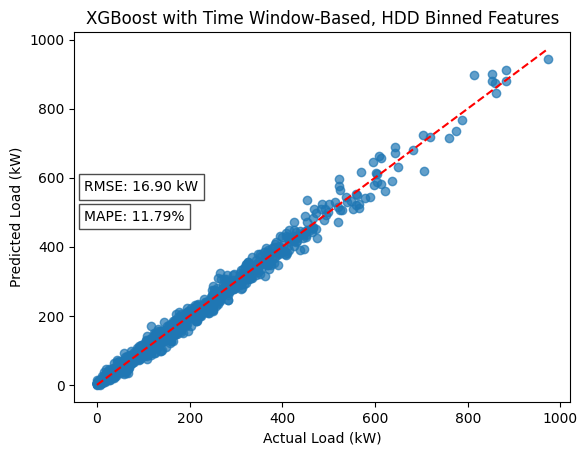

In [236]:
if retrain_xgb_windowed_hdd or not os.path.exists('models/xgb_windowed_hdd_model.pkl') or not os.path.exists('models/xgb_windowed_hdd_hyperparams.pkl'):
    xgb_windowed_hdd_model, xgb_windowed_hdd_best_hyperparams = tune_and_train_xgb(X_train_windowed_hdd, y_train_windowed_hdd)
    print("Best hyperparameters:", xgb_windowed_hdd_best_hyperparams)
    pickle.dump(xgb_windowed_hdd_model, open('models/xgb_windowed_hdd_model.pkl', 'wb'))
    pickle.dump(xgb_windowed_hdd_best_hyperparams, open('models/xgb_windowed_hdd_hyperparams.pkl', 'wb'))
else:
    xgb_windowed_hdd_model = pickle.load(open('models/xgb_windowed_hdd_model.pkl', 'rb'))
    xgb_windowed_hdd_best_hyperparams = pickle.load(open('models/xgb_windowed_hdd_hyperparams.pkl', 'rb'))


xgb_pred_windowed_hdd = xgb_windowed_hdd_model.predict(X_test_windowed_hdd)
xgb_pred_windowed_hdd = np.maximum(xgb_pred_windowed_hdd, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_windowed_hdd, xgb_pred_windowed_hdd, alpha=0.7)
ax.plot([y_test_windowed_hdd.min(), y_test_windowed_hdd.max()], [y_test_windowed_hdd.min(), y_test_windowed_hdd.max()], 'r--')
ax.set_xlabel(f'Actual Load (kW)')
ax.set_ylabel(f'Predicted Load (kW)')
ax.set_title(f'XGBoost with Time Window-Based, HDD Binned Features')
mask = y_test_windowed_hdd.values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_windowed_hdd.values[mask], xgb_pred_windowed_hdd[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_windowed_hdd.values, xgb_pred_windowed_hdd)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['Feature night_warm_Corr_HDH' 'Feature morning_warm_Corr_HDH'
 'Feature day_warm_Corr_HDH' 'Feature evening_warm_Corr_HDH']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['Feature night_warm_Corr_HDH' 'Feature morning_warm_Corr_HDH'
 'Feature day_warm_Corr_HDH' 'Feature evening_warm_Corr_HDH']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


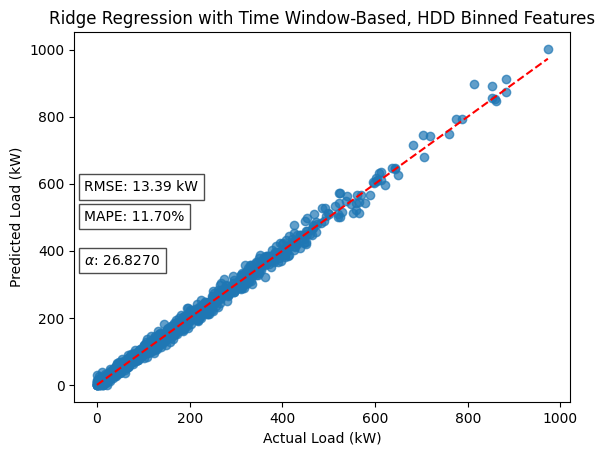

In [237]:
ridge_windowed_hdd_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5))
])

ridge_windowed_hdd_model.fit(X_train_windowed_hdd, y_train_windowed_hdd)
ridge_pred_windowed_hdd = ridge_windowed_hdd_model.predict(X_test_windowed_hdd)
ridge_pred_windowed_hdd = np.maximum(ridge_pred_windowed_hdd, 0)


fig, ax = plt.subplots()
ax.scatter(y_test_windowed_hdd, ridge_pred_windowed_hdd, alpha=0.7)
ax.plot([0, y_test_windowed_hdd.max()], [0, y_test_windowed_hdd.max()], 'r--')
ax.set_xlabel(f'Actual Load (kW)')
ax.set_ylabel(f'Predicted Load (kW)')
ax.set_title(f'Ridge Regression with Time Window-Based, HDD Binned Features')
mask = y_test_windowed_hdd.values != 0
if mask.sum() > 0:
    mape = mean_absolute_percentage_error(y_test_windowed_hdd.values[mask], ridge_pred_windowed_hdd[mask]) * 100
    ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
else:
    ax.text(0.02, 0.52, 'MAPE: N/A', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
rmse = root_mean_squared_error(y_test_windowed_hdd.values, ridge_pred_windowed_hdd)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {ridge_windowed_hdd_model.named_steps["ridge"].alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
plt.show()

## PCA

### Time Series

Evaluating PCA components - Ridge Regression:  11%|█         | 56/499 [01:47<14:12,  1.93s/it]

RMSE below threshold at n_components=114, stopping early.
Best n_components: 114 with RMSE: 0.00 kW


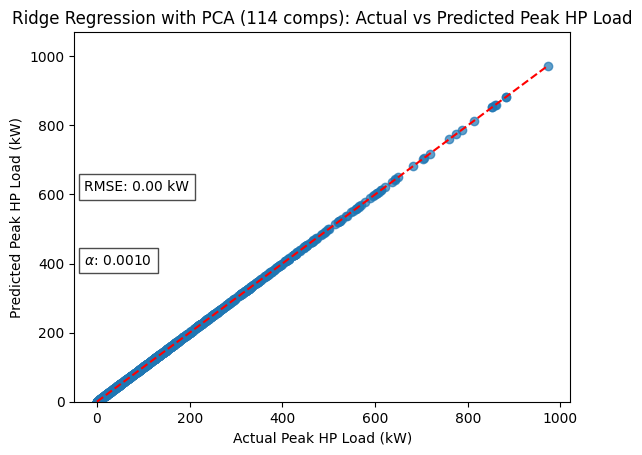

In [212]:
results_timeseries = {}
linreg_model_time_pca = RidgeCV(alphas=np.logspace(-3, 4, 50), cv=5)

total_loads_train = {}
total_loads_test = {}


for i in range(len(substations_df_train)):
    total_loads_train[i] = substations_df_train.iloc[i]['Total_Load'].values

total_loads_train_df = pd.DataFrame.from_dict(total_loads_train, orient='index').ffill(axis=1)

y_train_pca = substations_df_train['HP_Peak'].values

for i in range(len(substations_df_test)):
    total_loads_test[i] = substations_df_test.iloc[i]['Total_Load'].values

total_loads_test_df = pd.DataFrame.from_dict(total_loads_test, orient='index').ffill(axis=1)

y_test_pca = substations_df_test['HP_Peak'].values

for n_comp in trange(2, 1000, 2, desc='Evaluating PCA components - Ridge Regression'):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(total_loads_train_df)
    X_test_pca = pca.transform(total_loads_test_df)

    linreg_model_time_pca.fit(X_train_pca, y_train_pca)
    lin_pred_pca = linreg_model_time_pca.predict(X_test_pca)
    lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

    rmse = root_mean_squared_error(y_test_pca, lin_pred_pca)
    results_timeseries[n_comp] = rmse

    if rmse < 0.1:  # arbitrary threshold for "good enough" performance to stop early
        print(f'RMSE below threshold at n_components={n_comp}, stopping early.')
        break

best_pred_pca = min(results_timeseries, key=results_timeseries.get)
print(f'Best n_components: {best_pred_pca} with RMSE: {results_timeseries[best_pred_pca]:.2f} kW')

pca_time = PCA(n_components=best_pred_pca)
X_train_pca = pca_time.fit_transform(total_loads_train_df)
X_test_pca = pca_time.transform(total_loads_test_df)

linreg_model_time_pca.fit(X_train_pca, y_train_pca)
lin_pred_pca = linreg_model_time_pca.predict(X_test_pca)
lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_pca, lin_pred_pca, alpha=0.7)
ax.plot([y_test_pca.min(), y_test_pca.max()], [y_test_pca.min(), y_test_pca.max()], 'r--')
ax.set_xlabel('Actual Peak HP Load (kW)')
ax.set_ylabel('Predicted Peak HP Load (kW)')
ax.set_title(f'Ridge Regression with PCA ({best_pred_pca} comps): Actual vs Predicted Peak HP Load')
rmse = root_mean_squared_error(y_test_pca, lin_pred_pca)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.4, f'$\\alpha$: {linreg_model_time_pca.alpha_:.4f}', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.set_ylim([0, y_test_pca.max() * 1.1])
plt.show() 

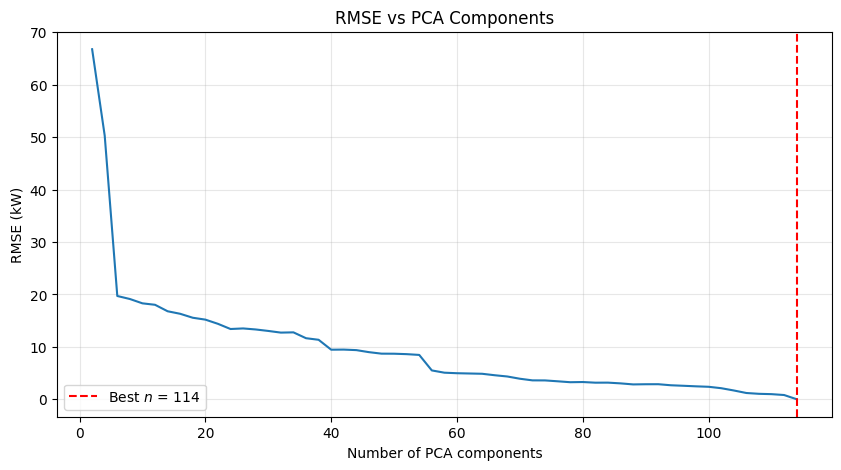

In [ ]:
rmse_dict = results_timeseries

x = np.array(sorted(rmse_dict.keys()))
y = np.array([rmse_dict[k] for k in x])

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker=' ', linestyle='-', color='tab:blue')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE (kW)')
plt.title('RMSE vs PCA Components')
plt.grid(alpha=0.3)

if 'best_pred_pca' in globals():
    plt.axvline(best_pred_pca, color='red', linestyle='--', label=f'Best $n$ = {best_pred_pca}')
    plt.legend()

plt.show()

In [ ]:
for n_comp in trange(2, 1000, 2, desc='Evaluating PCA components - XGBoost'):
    pca = PCA(n_components=n_comp)
    X_train_pca = pca.fit_transform(total_loads_train_df)

    xgb_model_time_pca = xgb.XGBRegressor(
        learning_rate=xgb_time_best_hyperparams['eta'],
        n_estimators=int(xgb_time_best_hyperparams['n_estimators']),
        max_depth=int(xgb_time_best_hyperparams['max_depth']),
        gamma=xgb_time_best_hyperparams['gamma'],
        subsample=xgb_time_best_hyperparams['subsample'],
        reg_alpha=xgb_time_best_hyperparams['reg_alpha'],
        reg_lambda=xgb_time_best_hyperparams['reg_lambda'],
        min_child_weight=int(xgb_time_best_hyperparams['min_child_weight']),
        colsample_bytree=xgb_time_best_hyperparams['colsample_bytree'],
        eval_metric="mae"
    )
    xgb_model_time_pca.fit(X_train_pca, y_train_pca)
    xgb_pred_pca = xgb_model_time_pca.predict(X_train_pca)
    xgb_pred_pca = np.maximum(xgb_pred_pca, 0) # ensure non-negative predictions

    rmse = root_mean_squared_error(y_test_pca, xgb_pred_pca)
    results_timeseries[n_comp] = rmse

    if rmse < 0.1:  # arbitrary threshold for "good enough" performance to stop early
        print(f'RMSE below threshold at n_components={n_comp}, stopping early.')
        break

pca_xgb_time_n_comp = min(results_timeseries, key=results_timeseries.get)
print(f'Best n_components: {best_pred_pca} with RMSE: {results_timeseries[best_pred_pca]:.2f} kW')


Evaluating PCA components - XGBoost: 100%|██████████| 499/499 [55:16<00:00,  6.65s/it]

Best n_components: 72 with RMSE: 21.67 kW


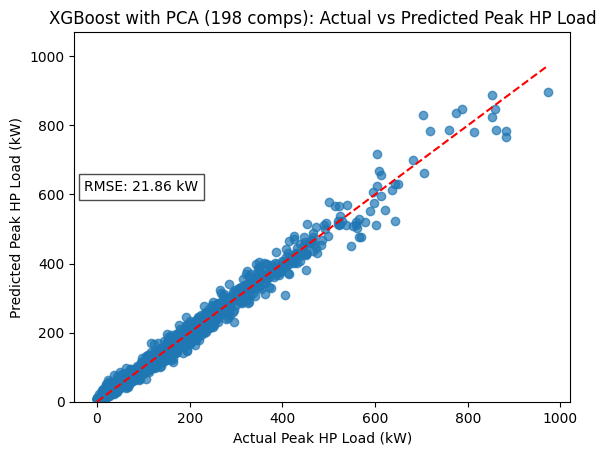

In [ ]:
pca = PCA(n_components=pca_xgb_time_n_comp)

X_train_pca = pca.fit_transform(total_loads_train_df)
X_test_pca = pca.transform(total_loads_test_df)

xgb_model_time_pca.fit(X_train_pca, y_train_pca)
xgb_pred_pca = xgb_model_time_pca.predict(X_test_pca)
xgb_pred_pca = np.maximum(xgb_pred_pca, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_pca, xgb_pred_pca, alpha=0.7)
ax.plot([y_test_pca.min(), y_test_pca.max()], [y_test_pca.min(), y_test_pca.max()], 'r--')
ax.set_xlabel('Actual Peak HP Load (kW)')
ax.set_ylabel('Predicted Peak HP Load (kW)')
ax.set_title(f'XGBoost with PCA ({pca_xgb_time_n_comp} comps): Actual vs Predicted Peak HP Load')
rmse = root_mean_squared_error(y_test_pca, xgb_pred_pca)
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.set_ylim([0, y_test_pca.max() * 1.1])
plt.show() 

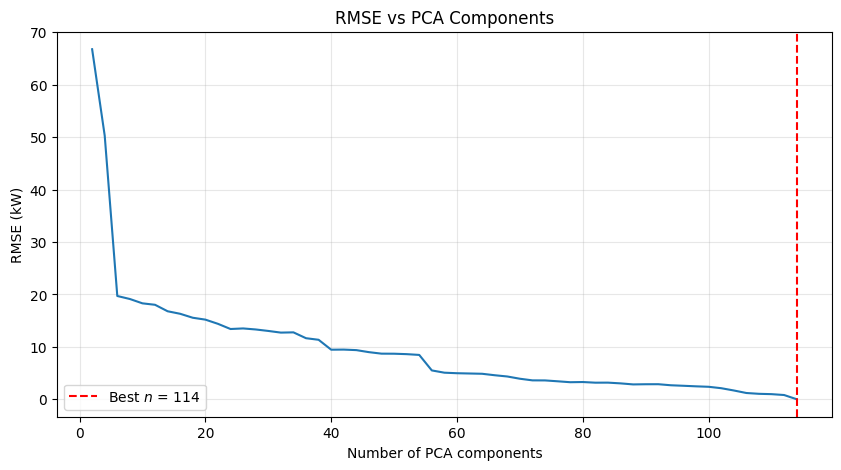

In [213]:
rmse_dict = results_timeseries

x = np.array(sorted(rmse_dict.keys()))
y = np.array([rmse_dict[k] for k in x])

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker=' ', linestyle='-', color='tab:blue')
plt.xlabel('Number of PCA components')
plt.ylabel('RMSE (kW)')
plt.title('RMSE vs PCA Components')
plt.grid(alpha=0.3)

if 'best_pred_pca' in globals():
    plt.axvline(best_pred_pca, color='red', linestyle='--', label=f'Best $n$ = {best_pred_pca}')
    plt.legend()

plt.show()

### Features

Best n_components (5-fold CV on train): 198


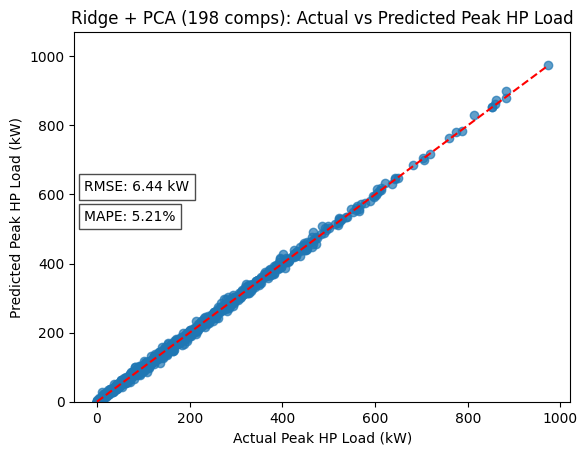

In [214]:
pca_pipe = Pipeline([
    ('pca', PCA()),
    ('ridge', RidgeCV(alphas=np.logspace(-3, 4, 30)))
])

param_grid = {'pca__n_components': list(range(2, min(200, X_train_time.shape[1]), 4))}

# FIX: select n_components via 5-fold CV on the TRAINING set only. The
# previous version swept n_components and picked whichever minimized test
# RMSE directly -- that is the test set leaking into model selection, and
# makes the reported test RMSE optimistic.
cv_search = GridSearchCV(
    pca_pipe, param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1
)
cv_search.fit(X_train_time, y_train_time['HP_Peak'])

best_pred_pca = cv_search.best_params_['pca__n_components']
print(f"Best n_components (5-fold CV on train): {best_pred_pca}")

# results_features now holds cross-validated RMSE per n_components, used
# only for the diagnostic plot in the next cell -- not for model selection.
results_features = {
    p['pca__n_components']: -s
    for p, s in zip(cv_search.cv_results_['params'], cv_search.cv_results_['mean_test_score'])
}

# Refit on the full training set with the selected n_components, then
# evaluate ONCE on the held-out test set.
RidgePCAFeat = cv_search.best_estimator_
lin_pred_pca = RidgePCAFeat.predict(X_test_time)
lin_pred_pca = np.maximum(lin_pred_pca, 0) # ensure non-negative predictions

fig, ax = plt.subplots()
ax.scatter(y_test_time['HP_Peak'], lin_pred_pca, alpha=0.7)
ax.plot([y_test_time['HP_Peak'].min(), y_test_time['HP_Peak'].max()], [y_test_time['HP_Peak'].min(), y_test_time['HP_Peak'].max()], 'r--')
ax.set_xlabel('Actual Peak HP Load (kW)')
ax.set_ylabel('Predicted Peak HP Load (kW)')
ax.set_title(f'Ridge + PCA ({best_pred_pca} comps): Actual vs Predicted Peak HP Load')
rmse = root_mean_squared_error(y_test_time['HP_Peak'].values, lin_pred_pca)
mask = y_test_time['HP_Peak'].values != 0
y_mape = y_test_time['HP_Peak'].values[mask]
lin_pred_mape = lin_pred_pca[mask]
mape = mean_absolute_percentage_error(y_mape, lin_pred_mape) * 100
ax.text(0.02, 0.52, f'MAPE: {mape:.2f}%', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.text(0.02, 0.6, f'RMSE: {rmse:.2f} kW', transform=ax.transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))
ax.set_ylim([0, y_test_time['HP_Peak'].max() * 1.1])
plt.show()

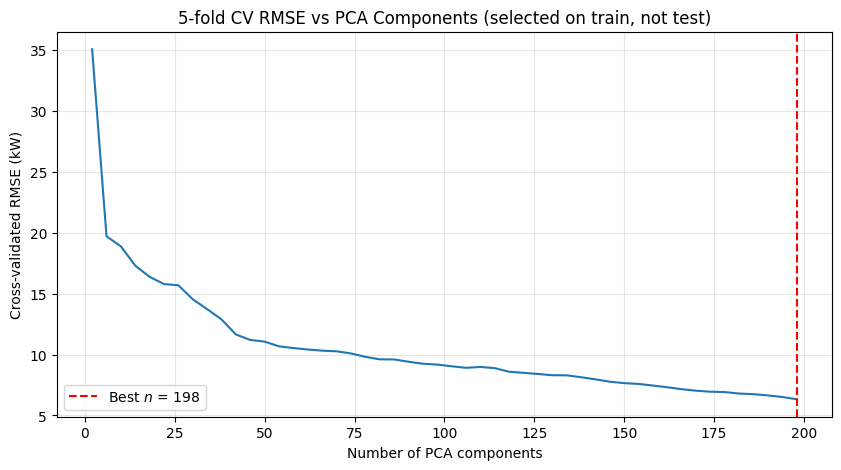

In [215]:
rmse_dict = results_features

x = np.array(sorted(rmse_dict.keys()))
y = np.array([rmse_dict[k] for k in x])

plt.figure(figsize=(10, 5))
plt.plot(x, y, marker=' ', linestyle='-', color='tab:blue')
plt.xlabel('Number of PCA components')
plt.ylabel('Cross-validated RMSE (kW)')
plt.title('5-fold CV RMSE vs PCA Components (selected on train, not test)')
plt.grid(alpha=0.3)

if 'best_pred_pca' in globals():
    plt.axvline(best_pred_pca, color='red', linestyle='--', label=f'Best $n$ = {best_pred_pca}')
    plt.legend()

plt.show()

## WPUQ Dataset

In [216]:
def detect_outliers_wpuq_15min(
    
s,
    lower=0,
    upper=10000,          # W
    days_window=14,       # same quarter-hour across ±14 days
    n_sigma=2.8,          # aggressive
    max_replace_run=4,    # up to 1 hour
    max_interp_run=8,     # up to 2 hours
    passes=2
):
    """
    Aggressive outlier removal for 15-minute WPuQ heat-pump series.

    Parameters
    ----------
    s : pd.Series
        15-minute time series with DateTimeIndex.
    lower, upper : float
        Physical plausibility bounds.
    days_window : int
        Number of days on each side for same-time-of-day seasonal baseline.
    n_sigma : float
        Hampel/MAD threshold on residuals.
    max_replace_run : int
        Consecutive flagged bins replaced by baseline.
    max_interp_run : int
        Consecutive flagged bins interpolated linearly.
    passes : int
        Number of cleaning passes.

    Returns
    -------
    cleaned : pd.Series
    outlier_mask : pd.Series[bool]
    baseline : pd.Series
    """
    s = s.copy().astype(float)
    steps_per_day = 96
    global_mask = pd.Series(False, index=s.index)

    def seasonal_baseline(x):
        base = pd.Series(index=x.index, dtype=float)
        vals = x.values
        n = len(x)

        for i in range(n):
            refs = []
            for d in range(1, days_window + 1):
                for sign in (-1, 1):
                    j = i + sign * d * steps_per_day
                    if 0 <= j < n and not np.isnan(vals[j]):
                        refs.append(vals[j])
            if refs:
                base.iloc[i] = np.median(refs)
            else:
                base.iloc[i] = np.nan

        # fallback near edges
        fallback = x.rolling(steps_per_day, center=True, min_periods=1).median()
        return base.fillna(fallback)

    cleaned = s.copy()

    for _ in range(passes):
        base = seasonal_baseline(cleaned)

        # physical outliers
        mask_phys = (cleaned < lower) | (cleaned > upper)

        # residual outliers
        resid = cleaned - base
        med_r = np.nanmedian(resid)
        mad_r = np.nanmedian(np.abs(resid - med_r))
        if not np.isfinite(mad_r) or mad_r == 0:
            mad_r = 1.0

        mask_resid = np.abs(resid - med_r) > (n_sigma * 1.4826 * mad_r)

        # gradient outliers
        dx = cleaned.diff()
        med_dx = np.nanmedian(dx)
        mad_dx = np.nanmedian(np.abs(dx - med_dx))
        if not np.isfinite(mad_dx) or mad_dx == 0:
            mad_dx = 1.0

        jump_prev = np.abs(cleaned - cleaned.shift(1)) > (3 * 1.4826 * mad_dx)
        jump_next = np.abs(cleaned - cleaned.shift(-1)) > (3 * 1.4826 * mad_dx)
        mask_grad = mask_resid & (jump_prev | jump_next)

        mask = (mask_phys | mask_resid | mask_grad).fillna(False)
        global_mask |= mask

        # handle runs
        run_id = (mask != mask.shift()).cumsum()
        run_len = mask.groupby(run_id).transform("size")

        replace_mask = mask & (run_len <= max_replace_run)
        interp_mask = mask & (run_len > max_replace_run) & (run_len <= max_interp_run)

        cleaned[replace_mask] = base[replace_mask]
        cleaned[interp_mask] = np.nan
        cleaned = cleaned.interpolate(limit=max_interp_run, limit_direction="both")

    baseline = seasonal_baseline(cleaned)
    return cleaned, global_mask, baseline


In [217]:
wpuq_data = h5py.File('data\\2019_data_15min.hdf5', 'r')
wpuq_transf_df = pd.DataFrame(np.array(wpuq_data['MISC']['ES1']['TRANSFORMER']['table'])) 
wpuq_transf_df['index'] = pd.to_datetime(wpuq_transf_df['index'], utc=True, origin='unix', unit='s')
wpuq_transf_df['P_TOT'] = wpuq_transf_df['P_TOT'] / 1000  # Convert W to kW

substation_total = wpuq_transf_df.set_index('index')
substation_total['Date'] = substation_total.index.date
substation_total['Time'] = substation_total.index.time
substation_total = substation_total[['P_TOT', 'Date', 'Time']]

In [218]:
wpuq_weather = h5py.File('data\\2019_weather.hdf5', 'r')
wpuq_weather_df = pd.DataFrame(np.array(wpuq_weather['WEATHER_SERVICE']['IN']['WEATHER_TEMPERATURE_TOTAL']['table']))
wpuq_weather_df['index'] = pd.to_datetime(wpuq_weather_df['index'], utc=True, origin='unix', unit='ns')

wpuq_weather_df = wpuq_weather_df.set_index('index').resample('15min').mean()[:-1]
wpuq_weather_df.index = wpuq_weather_df.index.shift(periods=1, freq='h')
wpuq_weather_df['Date'] = wpuq_weather_df.index.date
wpuq_weather_df['Time'] = wpuq_weather_df.index.time

# wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index.weekday < 5]  # Keep only weekdays
wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index >= pd.Timestamp('2019-01-01 00:00:00', tz='UTC')]
wpuq_weather_df = wpuq_weather_df[wpuq_weather_df.index <= pd.Timestamp('2019-12-31 23:45:00', tz='UTC')]  # Keep only 2019 data

wpuq_weather_df['TEMPERATURE:TOTAL'] = wpuq_weather_df['TEMPERATURE:TOTAL'].interpolate(method='time')
wpuq_weather_df['TEMPERATURE:TOTAL'] = wpuq_weather_df['TEMPERATURE:TOTAL'].ffill().bfill()

In [219]:
wpuq_hp_data = {}
wpuq_house_data = {}

full_year_no_weekends_wpuq = pd.date_range(start='2019-01-01', end='2019-12-31 23:45:00', freq='15min', tz='UTC')
# full_year_no_weekends_wpuq = full_year_no_weekends_wpuq[full_year_no_weekends_wpuq.weekday < 5]  # filter to weekdays

for building in wpuq_data['NO_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    house_df = pd.DataFrame(np.array(wpuq_data['NO_PV'][building]['HOUSEHOLD']['table']))
    house_df['index'] = pd.to_datetime(house_df['index'], utc=True, origin='unix', unit='s')

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    # hp_df = hp_df[hp_df['index'].dt.weekday < 5]  # filter to weekdays
    # house_df = house_df[house_df['index'].dt.weekday < 5]  # filter to weekdays


    if len(hp_df) >= len(full_year_no_weekends_wpuq) * 0.8:  # check if data has at least a year's worth of 15-min intervals

        hp_df = hp_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        hp_df_cleaned, hp_outliers, hp_baseline = detect_outliers_wpuq_15min(hp_df['P_TOT'])
        print(f"Building: {building}, Original HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, Cleaned HP Peak: {hp_df_cleaned.max() / 1000:.2f} kW")
        wpuq_hp_data[building] = hp_df_cleaned / 1000  # Convert W to kW
    if len(house_df) >= len(full_year_no_weekends_wpuq) * 0.8:

        house_df = house_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        house_df_cleaned, house_outliers, house_baseline = detect_outliers_wpuq_15min(house_df['P_TOT'])
        wpuq_house_data[building] = house_df_cleaned / 1000  # Convert W to kW

# --------------------------------

for building in wpuq_data['WITH_PV'].keys():
    hp_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HEATPUMP']['table']))
    hp_df['index'] = pd.to_datetime(hp_df['index'], utc=True, origin='unix', unit='s')
    house_df = pd.DataFrame(np.array(wpuq_data['WITH_PV'][building]['HOUSEHOLD']['table']))
    house_df['index'] = pd.to_datetime(house_df['index'], utc=True, origin='unix', unit='s')

    hp_df.dropna(inplace=True)
    house_df.dropna(inplace=True)

    # hp_df = hp_df[hp_df['index'].dt.weekday < 5]  # filter to weekdays
    # house_df = house_df[house_df['index'].dt.weekday < 5]  # filter to weekdays


    if len(hp_df) >= len(full_year_no_weekends_wpuq) * 0.8:  # check if data has at least a year's worth of 15-min intervals

        hp_df = hp_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        hp_df_cleaned, hp_outliers, hp_baseline = detect_outliers_wpuq_15min(hp_df['P_TOT'])
        print(f"Building: {building}, Original HP Peak: {hp_df['P_TOT'].max() / 1000:.2f} kW, Cleaned HP Peak: {hp_df_cleaned.max() / 1000:.2f} kW")
        wpuq_hp_data[building] = hp_df_cleaned / 1000  # Convert W to kW
    if len(house_df) >= len(full_year_no_weekends_wpuq) * 0.8:

        house_df = house_df.set_index('index').reindex(full_year_no_weekends_wpuq).interpolate(method='time')
        house_df_cleaned, house_outliers, house_baseline = detect_outliers_wpuq_15min(house_df['P_TOT'])
        wpuq_house_data[building] = house_df_cleaned / 1000  # Convert W to kW


Building: SFH10, Original HP Peak: 13.50 kW, Cleaned HP Peak: 11.08 kW
Building: SFH11, Original HP Peak: 8.41 kW, Cleaned HP Peak: 8.41 kW
Building: SFH12, Original HP Peak: 6.94 kW, Cleaned HP Peak: 6.94 kW
Building: SFH14, Original HP Peak: 11.76 kW, Cleaned HP Peak: 11.54 kW
Building: SFH16, Original HP Peak: 13.24 kW, Cleaned HP Peak: 12.24 kW
Building: SFH18, Original HP Peak: 6.31 kW, Cleaned HP Peak: 6.12 kW
Building: SFH19, Original HP Peak: 5.65 kW, Cleaned HP Peak: 5.65 kW
Building: SFH20, Original HP Peak: 11.87 kW, Cleaned HP Peak: 11.75 kW
Building: SFH21, Original HP Peak: 11.40 kW, Cleaned HP Peak: 11.40 kW
Building: SFH22, Original HP Peak: 6.17 kW, Cleaned HP Peak: 6.17 kW
Building: SFH23, Original HP Peak: 5.92 kW, Cleaned HP Peak: 5.92 kW
Building: SFH27, Original HP Peak: 6.04 kW, Cleaned HP Peak: 6.04 kW
Building: SFH28, Original HP Peak: 8.03 kW, Cleaned HP Peak: 8.03 kW
Building: SFH29, Original HP Peak: 5.83 kW, Cleaned HP Peak: 5.83 kW
Building: SFH3, Original

In [220]:
wpuq_hp_df = pd.DataFrame(wpuq_hp_data).reset_index(drop=True)
wpuq_house_df = pd.DataFrame(wpuq_house_data).reset_index(drop=True)

wpuq_total_hp = wpuq_hp_df.sum(axis=1)
wpuq_total_house = wpuq_house_df.sum(axis=1)

wpuq_total = {}

wpuq_total['Load'] = wpuq_total_hp.values + wpuq_total_house.values
wpuq_total['Date'] = wpuq_weather_df['Date'].values
wpuq_total['Time'] = wpuq_weather_df['Time'].values

wpuq_total_df = pd.DataFrame(wpuq_total, index=wpuq_weather_df.index)

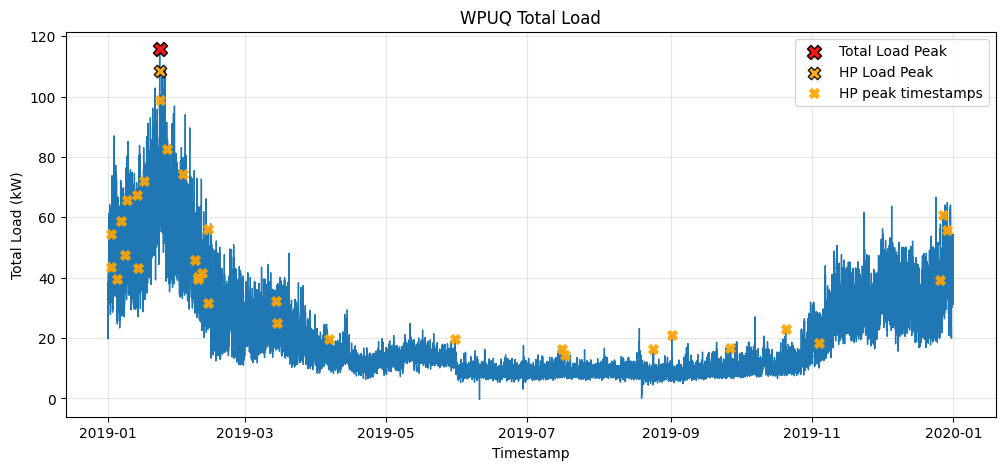

In [221]:
plt.figure(figsize=(12, 5))
plt.plot(wpuq_total_df.index, wpuq_total_df['Load'], lw=1)
plt.xlabel('Timestamp')
plt.ylabel('Total Load (kW)')
plt.title('WPUQ Total Load')

total_peak_ts = wpuq_total_df['Load'].idxmax()
total_peak_val = wpuq_total_df['Load'].max()

plt.scatter(
    total_peak_ts,
    total_peak_val,
    color='red',
    marker='X',
    s=100,
    alpha=0.9,
    edgecolors='black',
    linewidths=1.2,
    zorder=10,
    label='Total Load Peak'
)

hp_peak_ts = wpuq_total_df.index[wpuq_total_hp.idxmax()]
hp_peak_val = wpuq_total_hp.max()

plt.scatter(
    hp_peak_ts,
    hp_peak_val,
    color='orange',
    marker='X',
    s=80,
    alpha=0.9,
    edgecolors='black',
    linewidths=1.0,
    zorder=10,
    label='HP Load Peak'
)

hp_peak_times = []
hp_peak_vals = []

for col in wpuq_hp_df.columns:
    s = wpuq_hp_df[col].fillna(0)
    if s.empty:
        continue
    peak_ts = wpuq_total_df.index[s.idxmax()]
    hp_peak_times.append(peak_ts)
    hp_peak_vals.append(wpuq_total_df.at[peak_ts, 'Load'])

if hp_peak_times:
    plt.scatter(
        hp_peak_times,
        hp_peak_vals,
        color='orange',
        marker='X',
        s=50,
        alpha=0.9,
        edgecolors='orange',
        linewidths=0.8,
        zorder=10,
        label='HP peak timestamps'
    )
    plt.legend()
    plt.grid(alpha=0.3)
else:
    print("No HP peak timestamps aligned with total load index.")
plt.show()

In [222]:
wpuq_target = {}
wpuq_target['HP_Average'] = np.mean(wpuq_total_hp)
wpuq_target['HP_Peak'] = np.sum([wpuq_hp_df[hid].max() for hid in wpuq_hp_df.columns])
wpuq_target['HP_Simult_Peak'] = wpuq_total_hp.max()
wpuq_target['HP_Capacity_Factor'] = np.mean(wpuq_total_hp) / np.max(wpuq_total_hp)
wpuq_target['HP_Total_Energy'] = wpuq_total_hp.sum() / 4
wpuq_target['HP_Simult_Factor'] = np.max(wpuq_total_hp) / wpuq_target['HP_Peak']

In [223]:
wpuq_total_no_weekends = wpuq_total_df[wpuq_total_df.index.weekday < 5]
wpuq_weather_no_weekends = wpuq_weather_df[wpuq_weather_df.index.weekday < 5]

dailyLoad = wpuq_total_no_weekends.pivot(index='Date', columns='Time', values='Load').ffill()

dailyWeather = wpuq_weather_no_weekends.pivot(index='Date', columns='Time', values='TEMPERATURE:TOTAL').ffill()

dailyWeather = dailyWeather[dailyWeather.index.isin(dailyLoad.index)]

T_base = 15.0

hdh = np.maximum(0, T_base - dailyWeather)

dailyFeatures = {}
dailyFeatures['Mean'] = dailyLoad.mean(axis=0)
dailyFeatures['Std'] = dailyLoad.std(axis=0)
dailyFeatures['Min'] = dailyLoad.min(axis=0)
dailyFeatures['Max'] = dailyLoad.max(axis=0)
dailyFeatures['Skew'] = dailyLoad.skew(axis=0)
dailyFeatures['Kurtosis'] = dailyLoad.kurtosis(axis=0)
dailyFeatures['Max-Min'] = dailyLoad.max(axis=0) - dailyLoad.min(axis=0)
dailyFeatures['Cov'] = np.array([np.cov(dailyLoad.iloc[:,i], dailyWeather.iloc[:,i])[0][1] 
                                            for i in range(dailyLoad.shape[1])])
dailyFeatures['Corr_Pearson'] = pearsonr(x=dailyLoad, y=dailyWeather, axis=0).statistic
dailyFeatures['Corr_HDH'] = pearsonr(x=dailyLoad, y=hdh, axis=0).statistic

dailyFeaturesDf = pd.DataFrame(dailyFeatures)

# features = {}
# features['Mean'] = dailyFeaturesDf.mean()
# features['Std'] = dailyFeaturesDf.std()
# features['Min'] = dailyFeaturesDf.min()
# features['Max'] = dailyFeaturesDf.max()
# features['Median'] = dailyFeaturesDf.median()

wpuq_features = {}

for key_main in dailyFeaturesDf.keys():
    for key_sub in dailyFeaturesDf.index:
        wpuq_features[f'Feature {key_main}_{key_sub}'] = dailyFeaturesDf[key_main][key_sub]

wpuq_featuresDf = pd.DataFrame.from_dict(wpuq_features, orient='index').T

corr_cols = [c for c in wpuq_featuresDf.columns if 'Corr' in c]
other_cols = [c for c in wpuq_featuresDf.columns if c not in corr_cols]

wpuq_featuresDf[corr_cols] = wpuq_featuresDf[corr_cols].apply(lambda col: col.fillna(col.median()))
wpuq_featuresDf[other_cols] = wpuq_featuresDf[other_cols].fillna(0)


# ADD: per-household normalized magnitude features. Mean/Std/Min/Max/
# Max-Min/Cov all scale with the number of households in the substation;
# dividing by size removes that confound so the 864 raw features and their
# per-household counterparts both reach the model, and it can use whichever
# is more informative for a given time slot.

peak_load = wpuq_total_no_weekends['Load'].max()
magnitude_keys = ['Mean', 'Std', 'Min', 'Max', 'Max-Min', 'Cov']

for col in list(wpuq_featuresDf.columns):
    if col == 'HP_Peak':
        continue
    if any(col.startswith(f'Feature {k}_') for k in magnitude_keys):
        wpuq_featuresDf[f'{col}_per_hh'] = wpuq_featuresDf[col] / peak_load



C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_27428\3061816166.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wpuq_featuresDf[f'{col}_per_hh'] = wpuq_featuresDf[col] / peak_load
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_27428\3061816166.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  wpuq_featuresDf[f'{col}_per_hh'] = wpuq_featuresDf[col] / peak_load
C:\Users\VENANCIA\AppData\Local\Temp\ipykernel_27428\3061816166.py:64: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

In [238]:
wpuq_features_windowed_hdd = extract_windowed_hdd_features_from_series(
    load_series=wpuq_total_df["Load"],
    temp_series=wpuq_weather_df["TEMPERATURE:TOTAL"],
    resolution=15,
    T_base=15.0,
    mild_thresh=10.0,
    cold_thresh=25.0,
    **build_windowed_hdd_kwargs()
)

wpuq_features_windowed_hddDf = pd.DataFrame([wpuq_features_windowed_hdd], index=["WPUQ"])

In [239]:
x_wpuq, y_wpuq = daily_min_max_heating_season(
    wpuq_weather_df['TEMPERATURE:TOTAL'],
    wpuq_total_df['Load'],
    heating_season_thresh=15.0
)

base_load_wpuq, hp_sensitivity_wpuq, T_balance_wpuq, r2_wpuq = fit_hockey_stick(x_wpuq, y_wpuq, T_BALANCE_BOUNDS)

print(f"WPUQ Hockey-Stick Fit: Base Load={base_load_wpuq:.2f} kW, "
      f"HP Sensitivity={hp_sensitivity_wpuq:.3f} kW/°C, "
      f"T_balance={T_balance_wpuq:.2f}°C, R²={r2_wpuq:.3f}")

WPUQ Hockey-Stick Fit: Base Load=14.66 kW, HP Sensitivity=4.378 kW/°C, T_balance=9.35°C, R²=0.579


In [240]:
wpuq_coeff_hourly = {}

wpuq_coeff_hourly[0] = {}

try:
    temp_h = wpuq_weather_df['TEMPERATURE:TOTAL'].resample('h').mean()
    load_h = wpuq_total_df['Load'].resample('h').mean()

    sm_data = pd.DataFrame({'Temperature': temp_h, 'Total_Load': load_h}).dropna()

    for group_name, hours in hour_groups.items():
        group_data = sm_data[sm_data.index.hour.isin(hours)]

        x = group_data['Temperature'].values
        y = group_data['Total_Load'].values

        if len(x) < MIN_HEATING_DAYS:
            continue

        try:
            base_load, hp_sensitivity, T_balance, r2 = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
        except Exception:
            continue

        wpuq_coeff_hourly[0][f'{group_name}_BaseLoad'] = base_load
        wpuq_coeff_hourly[0][f'{group_name}_Sensitivity'] = hp_sensitivity
        wpuq_coeff_hourly[0][f'{group_name}_TBalance'] = T_balance
        wpuq_coeff_hourly[0][group_name] = r2

except Exception:
    pass

wpuq_coeff_hourly_df = pd.DataFrame.from_dict(wpuq_coeff_hourly, orient='index')

In [241]:
wpuq_sensitivities = wpuq_coeff_hourly_df[sensitivity_cols]

c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
c:\Users\VENANCIA\OneDrive - VITO\Desktop\NILM\.venv\Lib\site-packages\sklearn\impute\_base.py:577: UserWarning: Skipping features without any observed values: ['Feature night_warm_Corr_HDH' 'Feature morning_warm_Corr_HDH'
 'Feature day_warm_Corr_HDH' 'Feature evening_warm_Corr_HDH']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


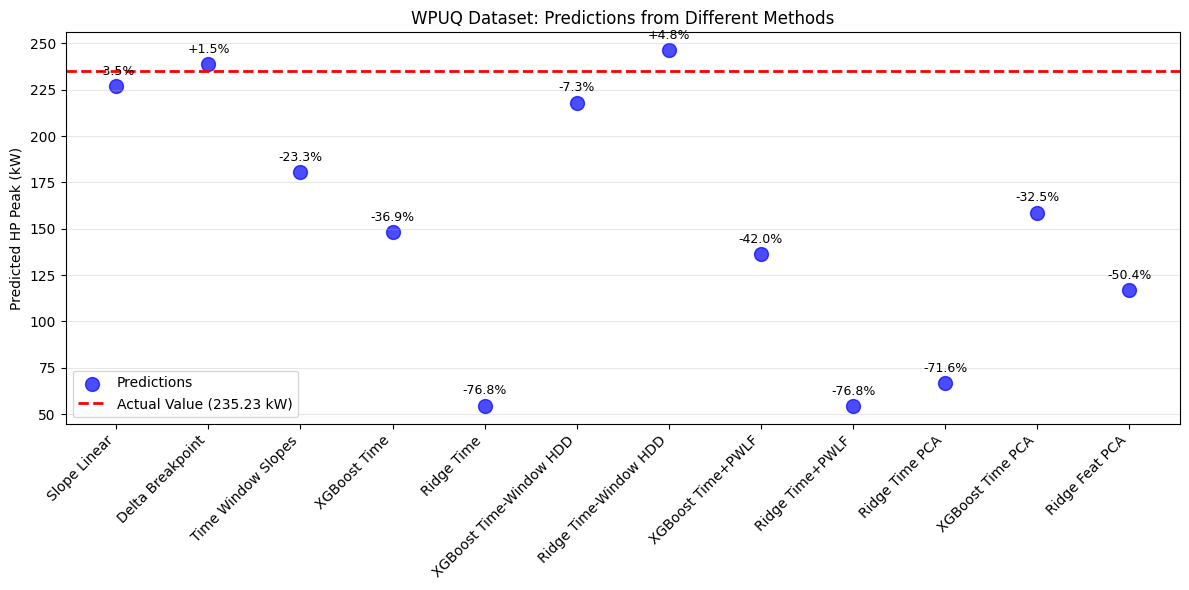

In [ ]:
slopePred = modelLinSlope.predict(np.array([[hp_sensitivity_wpuq]]))

nonSimDeltaPred_wpuq = nonSimDeltaFit.predict(np.array([[hp_sensitivity_wpuq]]))

sens_time_window_pred_wpuq = sensitivity_model.predict(wpuq_sensitivities)

X_wpuq_time = wpuq_featuresDf

if 'xgb_time_model' in globals():
    xgb_time_pred = xgb_time_model.predict(X_wpuq_time)
    xgb_time_pred = np.maximum(xgb_time_pred, 0) # ensure non-negative predictions

linreg_time_pred = linreg_time_model.predict(X_wpuq_time)
linreg_time_pred = np.maximum(linreg_time_pred, 0) # ensure no negative predictions

xgb_pred_windowed_hdd_wpuq = xgb_windowed_hdd_model.predict(wpuq_features_windowed_hddDf)
xgb_pred_windowed_hdd_wpuq = np.maximum(xgb_pred_windowed_hdd_wpuq, 0)

ridge_pred_windowed_hdd_wpuq = ridge_windowed_hdd_model.predict(wpuq_features_windowed_hddDf)
ridge_pred_windowed_hdd_wpuq = np.maximum(ridge_pred_windowed_hdd_wpuq, 0)

X_wpuq_pwlf = X_wpuq_time.join(pd.DataFrame({
    'Base_Load': base_load_wpuq,
    'HP_Sensitivity': hp_sensitivity_wpuq,
    'T_Balance': T_balance_wpuq,
}, index=X_wpuq_time.index))

if 'xgb_time_pwlf_model' in globals():
    xgb_time_pwlf_pred = xgb_time_pwlf_model.predict(X_wpuq_pwlf)
    xgb_time_pwlf_pred = np.maximum(xgb_time_pwlf_pred, 0) # ensure no negative predictions

if 'linreg_time_pwlf_model' in globals():
    linreg_time_pwlf_pred = linreg_time_pwlf_model.predict(X_wpuq_pwlf)
    linreg_time_pwlf_pred = np.maximum(linreg_time_pwlf_pred, 0) # ensure no negative predictions


pca = PCA(n_components=pca_xgb_time_n_comp)
pca.fit(total_loads_train_df)

wpuq_pca_time = pca.transform(wpuq_total_df['Load'].values.reshape(1, -1))

xgb_pred_time_pca_wpuq = xgb_model_time_pca.predict(wpuq_pca_time)
xgb_pred_time_pca_wpuq = np.maximum(xgb_pred_time_pca_wpuq, 0) # ensure no negative predictions

wpuq_pca_time = pca_time.transform(wpuq_total_df['Load'].values.reshape(1, -1))

linreg_time_pca_pred = linreg_model_time_pca.predict(wpuq_pca_time)
linreg_time_pca_pred = np.maximum(linreg_time_pca_pred, 0) # ensure no negative predictions

wpuq_pca_feat = RidgePCAFeat.predict(X_wpuq_time)

linreg_feat_pca_pred = np.maximum(wpuq_pca_feat, 0) # ensure no negative predictions

# Create comparison plot of all methods
fig, ax = plt.subplots(figsize=(12, 6))

methods = [
    ('Slope Linear', slopePred[0]),
    ('Delta Breakpoint', nonSimDeltaPred_wpuq[0]),
    ('Time Window Slopes', sens_time_window_pred_wpuq[0]),
    ('XGBoost Time', xgb_time_pred[0]),
    ('Ridge Time', linreg_time_pred[0]),
    ('XGBoost Time-Window HDD', xgb_pred_windowed_hdd_wpuq[0]),
    ('Ridge Time-Window HDD', ridge_pred_windowed_hdd_wpuq[0]),
    ('XGBoost Time+PWLF', xgb_time_pwlf_pred[0]),
    ('Ridge Time+PWLF', linreg_time_pwlf_pred[0]),
    ('Ridge Time PCA', linreg_time_pca_pred[0]),
    ('XGBoost Time PCA', xgb_pred_time_pca_wpuq[0]),
    ('Ridge Feat PCA', linreg_feat_pca_pred[0])
]

x_pos = range(len(methods))
method_names = [m[0] for m in methods]
predictions = [m[1] for m in methods]

actual = wpuq_target['HP_Peak']
for x, pred in zip(x_pos, predictions):
    pct_err = 100 * (pred - actual) / actual
    ax.annotate(
        f'{pct_err:+.1f}%',
        (x, pred),
        textcoords='offset points',
        xytext=(0, 6),
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

ax.scatter(x_pos, predictions, s=100, alpha=0.7, color='blue', label='Predictions')
ax.axhline(y=wpuq_target['HP_Peak'], color='red', linestyle='--', linewidth=2, label=f'Actual Value ({wpuq_target["HP_Peak"]:.2f} kW)')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, rotation=45, ha='right')
ax.set_ylabel('Predicted HP Peak (kW)')
ax.set_title('WPUQ Dataset: Predictions from Different Methods')
ax.grid(alpha=0.3, axis='y')
ax.legend()
fig.tight_layout()
plt.show()